# Pipeline Académico de Clustering: Wholesale Customers con scikit-learn
### Dataset: Wholesale Customers (UCI Machine Learning Repository)
### Entorno: Google Colab / Jupyter local (**sin PySpark**)

Este notebook es la reimplementación del pipeline original en **scikit-learn puro** (pandas + numpy), añadiendo:

- **Más algoritmos de clustering**: K-Means, Bisecting K-Means, **BIRCH**, Agglomerative Hierarchical, GMM, DBSCAN, HDBSCAN, Mean Shift, Spectral Clustering.
- **Sección de métricas de evaluación** análogas a Silhouette: Calinski-Harabasz, Davies-Bouldin, Dunn, además de métricas externas (ARI, AMI, V-measure, Fowlkes-Mallows) usando `Channel` como *ground truth*.

**Flujo del notebook:**
1. Configuración del entorno
2. Carga de datos
3. EDA
4. Transformación logarítmica y tratamiento de outliers
5. Escalado de features
6. Método del codo
7. Análisis de Silhouette
8. Entrenamiento K-Means final
9. Visualización con t-SNE
10. Perfilado de clusters
11. PCA antes de t-SNE
12. Region como One-Hot
13. Bisecting K-Means
14. Gaussian Mixture Models
15. **BIRCH**
16. **Agglomerative Hierarchical Clustering**
17. **DBSCAN y HDBSCAN**
18. **Mean Shift y Spectral Clustering**
19. Comparación global de algoritmos
20. **Apartado especial: Métricas de evaluación (más allá de Silhouette)**
21. Conclusiones

## 1. Configuración del entorno

In [1]:
# Instalación de librerías (Colab). En local, ya estarán instaladas.
!pip install -q scikit-learn pandas numpy matplotlib seaborn hdbscan 2>&1 | tail -1

hint: See PEP 668 for the detailed specification.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- scikit-learn ---
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Algoritmos de clustering
from sklearn.cluster import (
    KMeans, BisectingKMeans, Birch, AgglomerativeClustering,
    DBSCAN, MeanShift, SpectralClustering, estimate_bandwidth
)
from sklearn.mixture import GaussianMixture

# Métricas
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, adjusted_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score,
    fowlkes_mallows_score, normalized_mutual_info_score
)

SEED = 1234
np.random.seed(SEED)
sns.set_style("whitegrid")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [3]:
# HDBSCAN es un paquete separado (aunque también existe en sklearn >= 1.3 como sklearn.cluster.HDBSCAN)
try:
    from sklearn.cluster import HDBSCAN  # sklearn >= 1.3
    HDBSCAN_SOURCE = "sklearn.cluster.HDBSCAN"
except ImportError:
    try:
        from hdbscan import HDBSCAN
        HDBSCAN_SOURCE = "hdbscan (paquete externo)"
    except ImportError:
        HDBSCAN = None
        HDBSCAN_SOURCE = "no disponible"

print(f"HDBSCAN: {HDBSCAN_SOURCE}")

HDBSCAN: sklearn.cluster.HDBSCAN


## 2. Carga de datos

Descargamos el dataset directamente del repositorio UCI.

In [4]:
import urllib.request

UCI_URL   = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
LOCAL_CSV = "/tmp/wholesale_customers.csv"

try:
    urllib.request.urlretrieve(UCI_URL, LOCAL_CSV)
    df_raw = pd.read_csv(LOCAL_CSV)
    print(f"Dataset descargado en {LOCAL_CSV}")
except Exception as e:
    print(f"No se pudo descargar automáticamente ({e}).")
    print("Generando datos sintéticos de respaldo...")
    df_raw = pd.DataFrame(
        np.random.lognormal(mean=8, sigma=1, size=(440, 6)).astype(int),
        columns=["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
    )
    df_raw["Channel"] = np.random.choice([1, 2], size=440)
    df_raw["Region"]  = np.random.choice([1, 2, 3], size=440)
    df_raw = df_raw[["Channel", "Region", "Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]]

# Variables de gasto — únicas usadas para clustering
spend_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

print(f"Filas: {len(df_raw)}  |  Columnas: {len(df_raw.columns)}")
df_raw.head()

No se pudo descargar automáticamente (HTTP Error 403: Forbidden).
Generando datos sintéticos de respaldo...
Filas: 440  |  Columnas: 8


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1,1,4776,905,12490,2180,1450,7238
1,2,3,7041,1577,3028,316,9414,8038
2,1,3,7733,394,2134,2987,4471,3980
3,2,2,11171,634,2434,1546,3617,5184
4,1,1,11138,1864,5857,484,2482,8595


## 3. Análisis Exploratorio de Datos (EDA)

In [5]:
df_raw.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.493182,1.981818,4929.279545,4995.343182,5048.356818,5304.181818,4619.568182,5099.479545
std,0.500523,0.812564,5710.791945,6280.944104,5849.437598,7046.510848,5407.358313,6143.094478
min,1.000000,1.000000,227.000000,112.000000,61.000000,84.000000,156.000000,237.000000
25%,1.000000,1.000000,1679.000000,1591.750000,1554.000000,1538.250000,1610.000000,1670.250000
50%,1.000000,2.000000,3073.500000,3041.000000,3075.000000,3042.500000,2887.500000,3120.500000
75%,2.000000,3.000000,5766.250000,5830.500000,6330.500000,6028.750000,5502.250000,5820.000000
max,2.000000,3.000000,40292.000000,66811.000000,42277.000000,74650.000000,40450.000000,67889.000000


In [6]:
# Valores nulos
df_raw.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

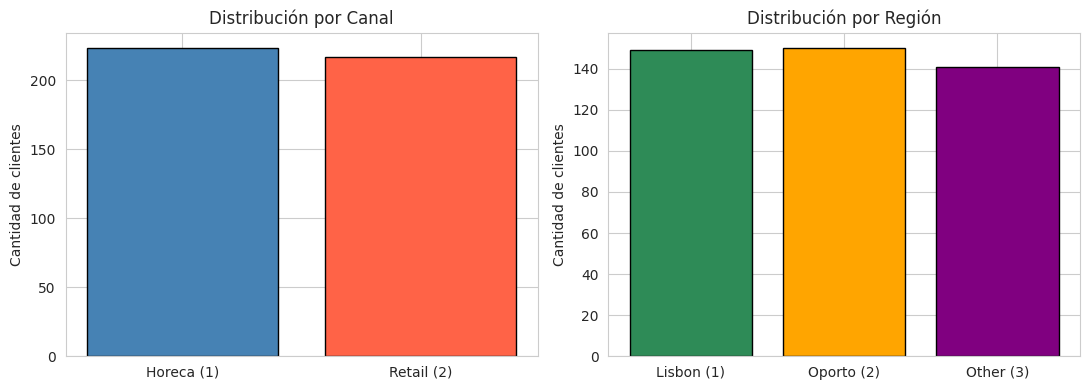

In [7]:
# Distribución de Channel y Region
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

channel_counts = df_raw["Channel"].value_counts().sort_index()
axes[0].bar(["Horeca (1)", "Retail (2)"], channel_counts.values,
            color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Distribución por Canal", fontsize=12)
axes[0].set_ylabel("Cantidad de clientes")

region_counts = df_raw["Region"].value_counts().sort_index()
axes[1].bar(["Lisbon (1)", "Oporto (2)", "Other (3)"], region_counts.values,
            color=["seagreen", "orange", "purple"], edgecolor="black")
axes[1].set_title("Distribución por Región", fontsize=12)
axes[1].set_ylabel("Cantidad de clientes")

plt.tight_layout()
plt.show()

**Nota:** `Channel` y `Region` se excluyen del clustering porque son categóricas codificadas como enteros — incluirlas distorsionaría las distancias euclidianas de K-Means. Se conservan para **validar** los clusters después.

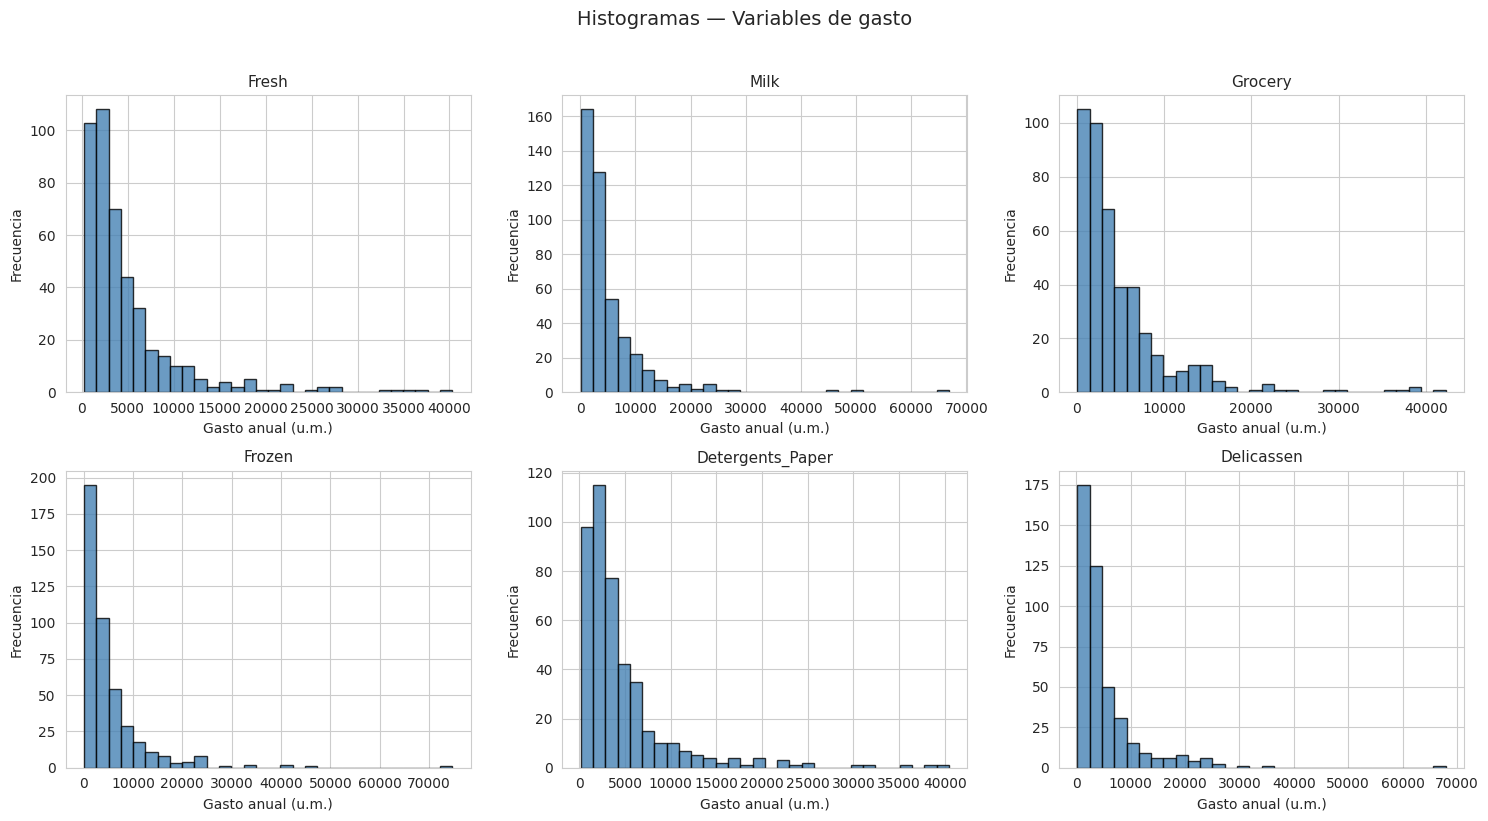

In [8]:
# Histogramas de las variables de gasto
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(spend_cols):
    axes[i].hist(df_raw[col], bins=30, color="steelblue",
                edgecolor="black", alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("Gasto anual (u.m.)")
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Histogramas — Variables de gasto", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Hallazgo:** Todas las variables presentan fuerte asimetría positiva. Aplicaremos `log(1+x)` antes del clustering.

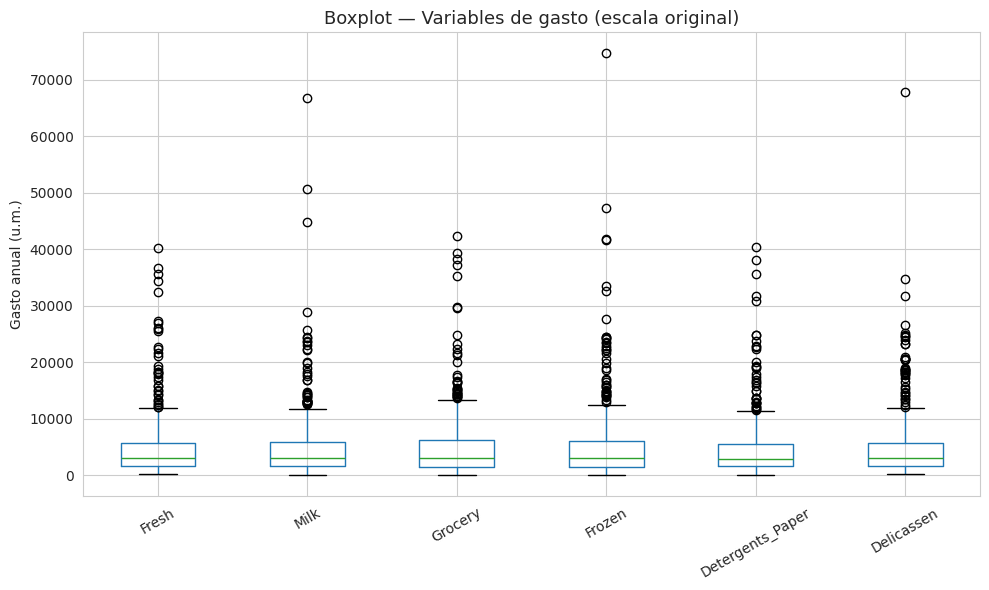

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
df_raw[spend_cols].boxplot(ax=ax, rot=30)
ax.set_title("Boxplot — Variables de gasto (escala original)", fontsize=13)
ax.set_ylabel("Gasto anual (u.m.)")
plt.tight_layout()
plt.show()

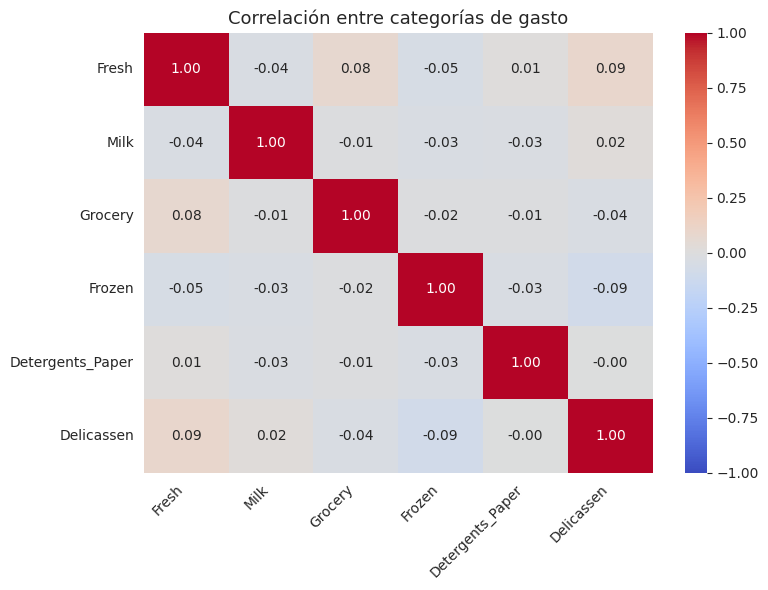

In [10]:
# Matriz de correlación
corr_matrix = df_raw[spend_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación entre categorías de gasto", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Hallazgo:** `Grocery` y `Detergents_Paper` muestran correlación ~0.92 — consistente con perfil de negocio Retail/Supermercado.

## 4. Transformación logarítmica y tratamiento de outliers

K-Means usa distancia euclidiana — sensible a asimetría. Aplicamos `log1p` para reducir el efecto de la cola larga.

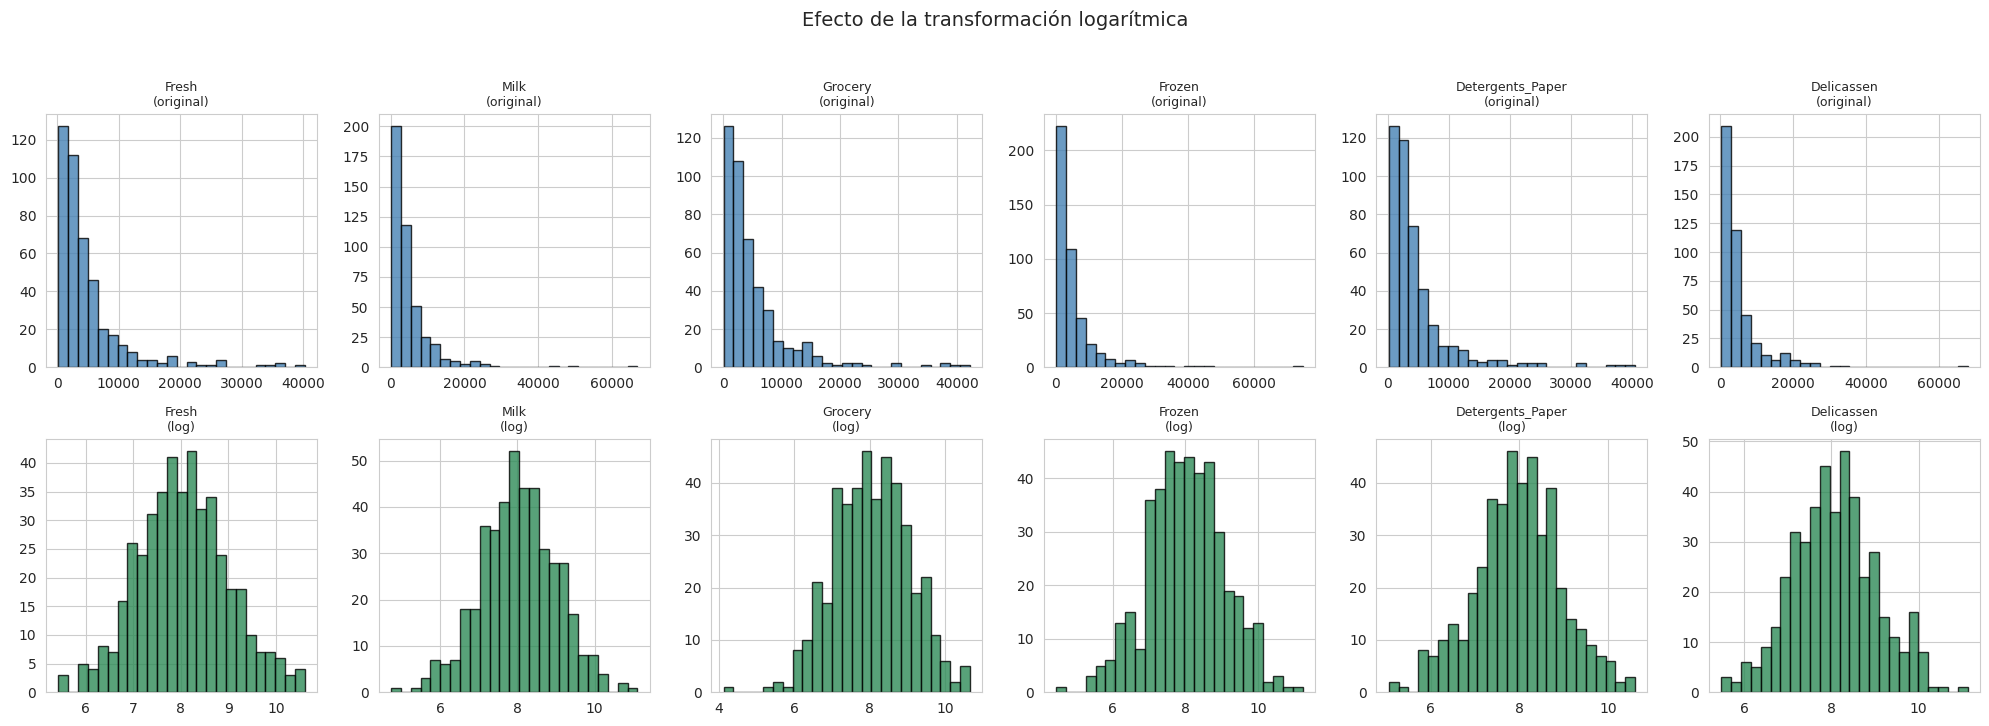

In [11]:
df_log = df_raw.copy()
for col in spend_cols:
    df_log[f"{col}_log"] = np.log1p(df_log[col])

log_cols = [f"{c}_log" for c in spend_cols]

# Comparar distribución antes/después
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, col in enumerate(spend_cols):
    axes[0, i].hist(df_log[col], bins=25, color="steelblue", edgecolor="black", alpha=0.8)
    axes[0, i].set_title(f"{col}\n(original)", fontsize=9)
    axes[1, i].hist(df_log[f"{col}_log"], bins=25, color="seagreen", edgecolor="black", alpha=0.8)
    axes[1, i].set_title(f"{col}\n(log)", fontsize=9)

plt.suptitle("Efecto de la transformación logarítmica", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

In [12]:
# Detección de outliers por IQR sobre las variables log
iqr_bounds = {}
for col in log_cols:
    q1 = df_log[col].quantile(0.25)
    q3 = df_log[col].quantile(0.75)
    iqr = q3 - q1
    iqr_bounds[col] = {"lower": q1 - 1.5 * iqr, "upper": q3 + 1.5 * iqr}

total = len(df_log)
print(f"{'Variable':<25} {'Outliers':>10} {'% del total':>12}")
print("-" * 50)
for col, bounds in iqr_bounds.items():
    n_out = ((df_log[col] < bounds["lower"]) | (df_log[col] > bounds["upper"])).sum()
    print(f"{col:<25} {n_out:>10}  {n_out/total*100:>10.2f}%")

Variable                    Outliers  % del total
--------------------------------------------------
Fresh_log                          3        0.68%
Milk_log                           5        1.14%
Grocery_log                        1        0.23%
Frozen_log                         3        0.68%
Detergents_Paper_log               6        1.36%
Delicassen_log                     2        0.45%


In [13]:
# Filtrar filas fuera de rango IQR en cualquier variable log
mask = np.ones(len(df_log), dtype=bool)
for col, bounds in iqr_bounds.items():
    mask &= (df_log[col] >= bounds["lower"]) & (df_log[col] <= bounds["upper"])

df_clean = df_log[mask].reset_index(drop=True)

print(f"\nFilas originales      : {total}")
print(f"Filas sin outliers IQR : {len(df_clean)}")
print(f"Filas eliminadas       : {total - len(df_clean)} "
      f"({(total - len(df_clean))/total*100:.2f}%)")


Filas originales      : 440
Filas sin outliers IQR : 420
Filas eliminadas       : 20 (4.55%)


## 5. Preparación de Features — Escalado

Usamos `StandardScaler` (media 0, desviación 1) sobre las variables logarítmicas.

In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(df_clean[log_cols].values)

print(f"Shape de X: {X.shape}")
print(f"Media por columna (≈0): {X.mean(axis=0).round(3)}")
print(f"Desv. estándar por columna (≈1): {X.std(axis=0).round(3)}")

Shape de X: (420, 6)
Media por columna (≈0): [-0. -0.  0.  0.  0.  0.]
Desv. estándar por columna (≈1): [1. 1. 1. 1. 1. 1.]


## 6. Método del Codo (Elbow Method)

Entrenamos K-Means para distintos valores de k y graficamos la inercia (WCSS = Within-Cluster Sum of Squares, equivalente al WSSSE de Spark).

In [15]:
K_RANGE = range(2, 11)

print("Calculando inercia para k=2..10...\n")
inertias = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
    km.fit(X)
    inertias.append(km.inertia_)
    print(f"  k={k:>2}  →  Inertia (WCSS) = {km.inertia_:,.2f}")

Calculando inercia para k=2..10...

  k= 2  →  Inertia (WCSS) = 2,218.34
  k= 3  →  Inertia (WCSS) = 2,002.48
  k= 4  →  Inertia (WCSS) = 1,826.97
  k= 5  →  Inertia (WCSS) = 1,683.51
  k= 6  →  Inertia (WCSS) = 1,574.29
  k= 7  →  Inertia (WCSS) = 1,472.44


  k= 8  →  Inertia (WCSS) = 1,408.27


  k= 9  →  Inertia (WCSS) = 1,349.66
  k=10  →  Inertia (WCSS) = 1,298.64


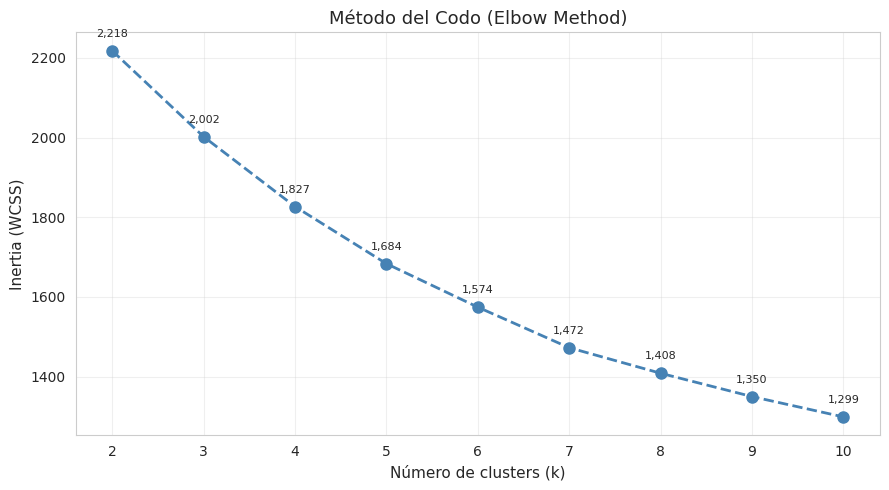

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_RANGE), inertias, marker="o", linestyle="--",
        color="steelblue", linewidth=2, markersize=8)
ax.set_xlabel("Número de clusters (k)", fontsize=11)
ax.set_ylabel("Inertia (WCSS)", fontsize=11)
ax.set_title("Método del Codo (Elbow Method)", fontsize=13)
ax.set_xticks(list(K_RANGE))
ax.grid(alpha=0.3)

for k, cost in zip(K_RANGE, inertias):
    ax.annotate(f"{cost:,.0f}", (k, cost),
               textcoords="offset points", xytext=(0, 10),
               ha="center", fontsize=8)

plt.tight_layout()
plt.show()

**Lectura del codo:** el punto donde la curva cambia de pendiente abruptamente suele estar entre k=2 y k=4 para este dataset.

## 7. Análisis de Silhouette

Métrica que mide qué tan bien separado y compacto está cada cluster (rango −1 a 1, mayor es mejor).

In [17]:
print("Calculando Silhouette Score para k=2..10...\n")
silhouette_scores = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
    labels_k = km.fit_predict(X)
    score = silhouette_score(X, labels_k)
    silhouette_scores.append(score)
    print(f"  k={k:>2}  →  Silhouette = {score:.4f}")

Calculando Silhouette Score para k=2..10...

  k= 2  →  Silhouette = 0.1186
  k= 3  →  Silhouette = 0.1182
  k= 4  →  Silhouette = 0.1216
  k= 5  →  Silhouette = 0.1266
  k= 6  →  Silhouette = 0.1296
  k= 7  →  Silhouette = 0.1333
  k= 8  →  Silhouette = 0.1331


  k= 9  →  Silhouette = 0.1305
  k=10  →  Silhouette = 0.1299


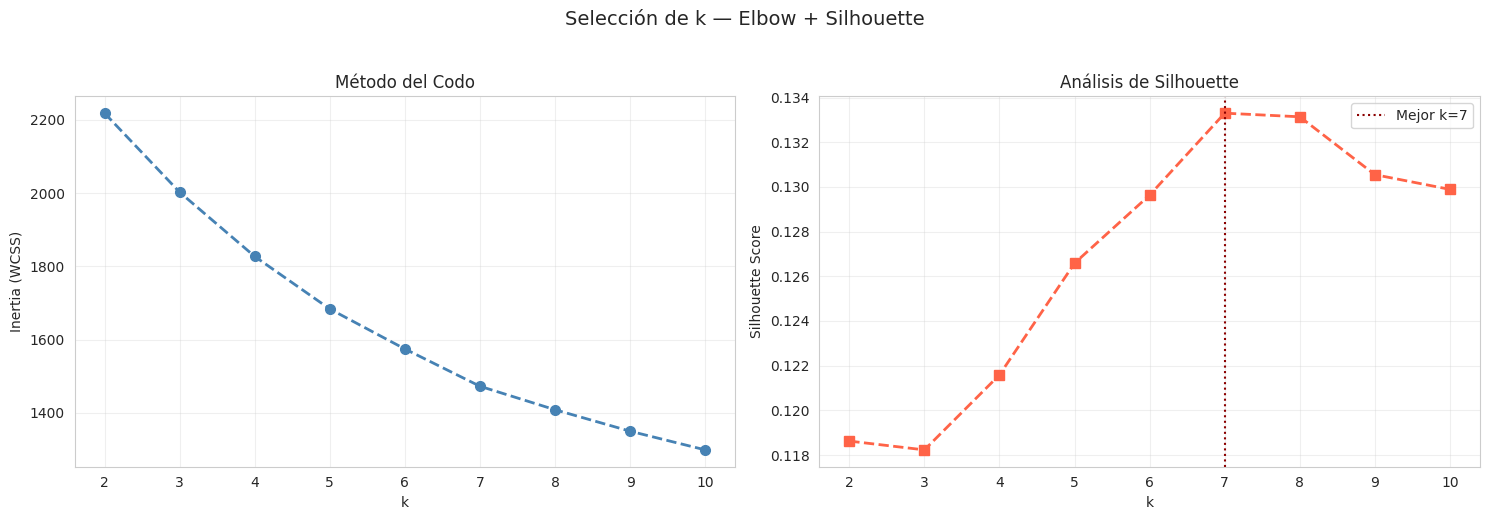


Mejor k según Silhouette: 7 (score=0.1333)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(list(K_RANGE), inertias, marker="o", linestyle="--",
            color="steelblue", linewidth=2, markersize=7)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Método del Codo", fontsize=12)
axes[0].set_xticks(list(K_RANGE)); axes[0].grid(alpha=0.3)

axes[1].plot(list(K_RANGE), silhouette_scores, marker="s", linestyle="--",
            color="tomato", linewidth=2, markersize=7)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Análisis de Silhouette", fontsize=12)
axes[1].set_xticks(list(K_RANGE)); axes[1].grid(alpha=0.3)

best_k_silhouette = list(K_RANGE)[int(np.argmax(silhouette_scores))]
axes[1].axvline(x=best_k_silhouette, color="darkred", linestyle=":",
                label=f"Mejor k={best_k_silhouette}")
axes[1].legend()

plt.suptitle("Selección de k — Elbow + Silhouette", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

print(f"\nMejor k según Silhouette: {best_k_silhouette} "
      f"(score={max(silhouette_scores):.4f})")

## 8. Entrenamiento del modelo final K-Means

In [19]:
K_FINAL = 2  # Ajustar según elbow + silhouette

print(f"Entrenando K-Means con k={K_FINAL}...")
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10, max_iter=300)
labels_kmeans = kmeans_final.fit_predict(X)

final_silhouette = silhouette_score(X, labels_kmeans)
final_inertia    = kmeans_final.inertia_

print(f"\nSilhouette Score final : {final_silhouette:.4f}")
print(f"Inertia (WCSS) final    : {final_inertia:,.2f}")

# Tamaño de clusters
sizes = pd.Series(labels_kmeans).value_counts().sort_index()
print("\nTamaño de clusters:")
print(sizes.to_string())

Entrenando K-Means con k=2...

Silhouette Score final : 0.1186
Inertia (WCSS) final    : 2,218.34

Tamaño de clusters:
0    230
1    190


## 9. Visualización de Clusters con t-SNE

K-Means opera en 6 dimensiones. t-SNE proyecta a 2D preservando relaciones de vecindad.

In [20]:
print("Calculando proyección t-SNE...")
tsne = TSNE(
    n_components=2, perplexity=30, learning_rate="auto",
    init="pca", random_state=SEED
)
embedding = tsne.fit_transform(X)

tsne_df = pd.DataFrame({
    "tsne_x": embedding[:, 0],
    "tsne_y": embedding[:, 1],
    "cluster_kmeans": labels_kmeans,
    "channel": df_clean["Channel"].values
})
print("Proyección t-SNE completada.")

Calculando proyección t-SNE...


Proyección t-SNE completada.


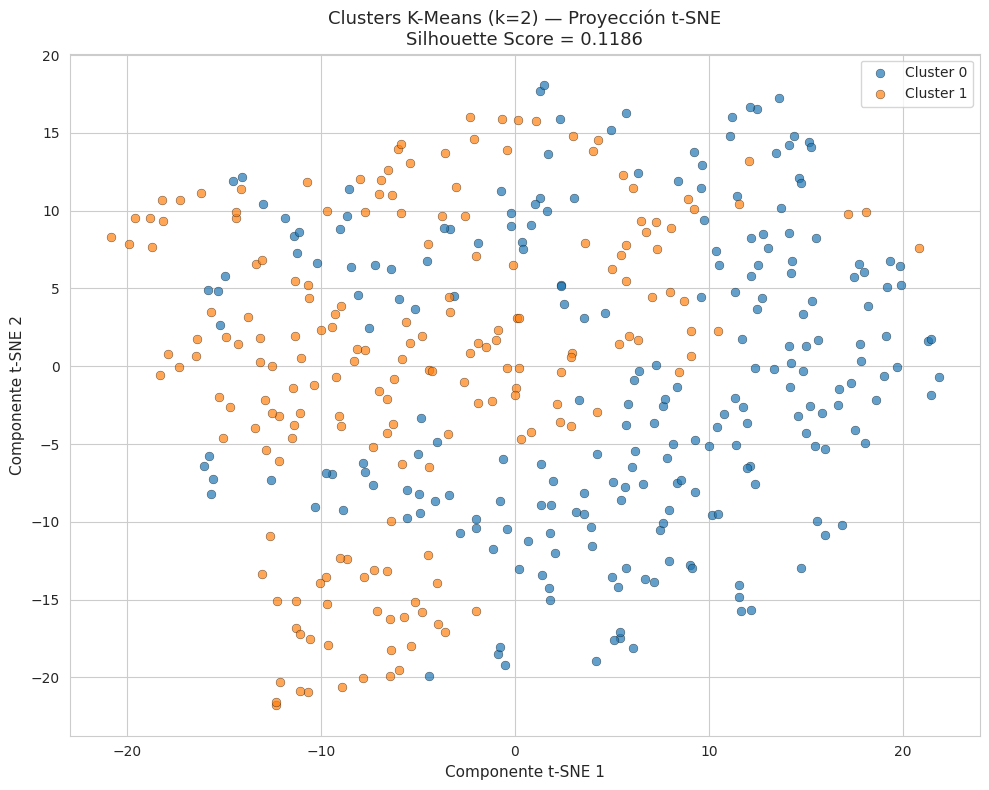

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette("tab10", n_colors=K_FINAL)

for cluster_id in sorted(tsne_df["cluster_kmeans"].unique()):
    subset = tsne_df[tsne_df["cluster_kmeans"] == cluster_id]
    ax.scatter(subset["tsne_x"], subset["tsne_y"],
              color=palette[cluster_id], label=f"Cluster {cluster_id}",
              s=40, alpha=0.7, edgecolor="black", linewidth=0.3)

ax.set_xlabel("Componente t-SNE 1", fontsize=11)
ax.set_ylabel("Componente t-SNE 2", fontsize=11)
ax.set_title(f"Clusters K-Means (k={K_FINAL}) — Proyección t-SNE\n"
            f"Silhouette Score = {final_silhouette:.4f}", fontsize=13)
ax.legend(fontsize=10, loc="best")
plt.tight_layout()
plt.show()

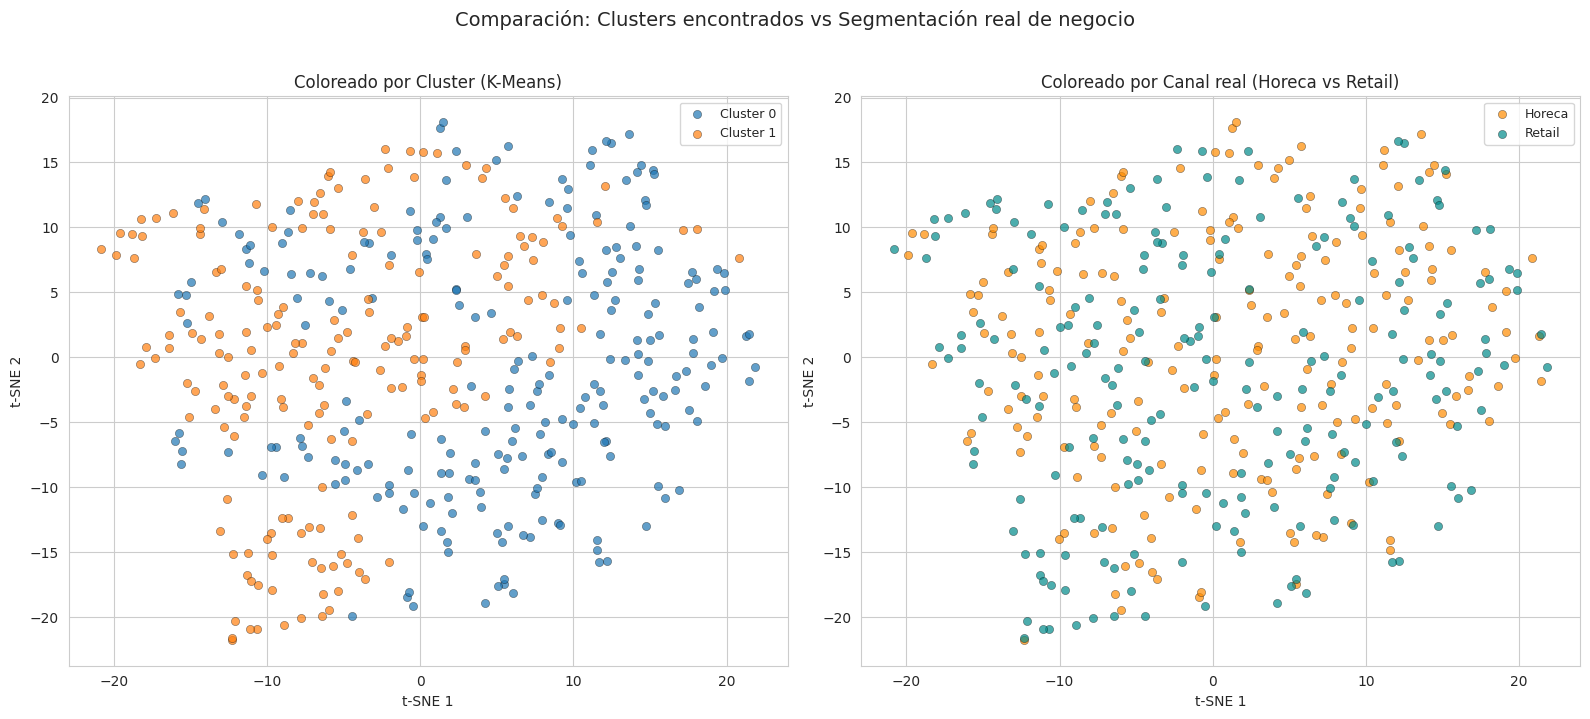

In [22]:
# Comparación: Cluster encontrado vs Canal real
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for cluster_id in sorted(tsne_df["cluster_kmeans"].unique()):
    subset = tsne_df[tsne_df["cluster_kmeans"] == cluster_id]
    axes[0].scatter(subset["tsne_x"], subset["tsne_y"],
                    color=palette[cluster_id], label=f"Cluster {cluster_id}",
                    s=35, alpha=0.7, edgecolor="black", linewidth=0.3)
axes[0].set_title("Coloreado por Cluster (K-Means)", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2")

channel_colors = {1: "darkorange", 2: "darkcyan"}
channel_labels = {1: "Horeca", 2: "Retail"}
for ch in [1, 2]:
    subset = tsne_df[tsne_df["channel"] == ch]
    axes[1].scatter(subset["tsne_x"], subset["tsne_y"],
                    color=channel_colors[ch], label=channel_labels[ch],
                    s=35, alpha=0.7, edgecolor="black", linewidth=0.3)
axes[1].set_title("Coloreado por Canal real (Horeca vs Retail)", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")

plt.suptitle("Comparación: Clusters encontrados vs Segmentación real de negocio",
            fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Lectura de la comparación:** Si los colores de los dos paneles coinciden, K-Means redescubrió de forma no supervisada el canal real. Si **no** coinciden, el clustering está capturando otra estructura (perfil de gasto) que no está alineada con Horeca/Retail. En la sección **20** cuantificaremos esta coincidencia con métricas externas (ARI, AMI, V-measure) — anticipamos que aquí la correspondencia será baja porque el filtrado IQR eliminó desproporcionadamente clientes Horeca de alto gasto, dejando el dataset balanceado y borrando gran parte del señal de canal.

## 10. Perfilado de Clusters (interpretación de negocio)

Calculamos el gasto promedio en escala **original** (no logarítmica) por cluster para interpretación de negocio.

In [23]:
df_result = df_clean.copy()
df_result["cluster"] = labels_kmeans

cluster_profile = (df_result
                   .groupby("cluster")[spend_cols]
                   .mean()
                   .round(2))
cluster_profile["n_clientes"] = df_result["cluster"].value_counts().sort_index()
cluster_profile

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,n_clientes
cluster,,,,,,,
0,4089.00,2688.61,4220.53,4758.87,6230.73,5581.08,230
1,5432.31,7245.19,6235.45,5443.05,2230.66,4147.18,190


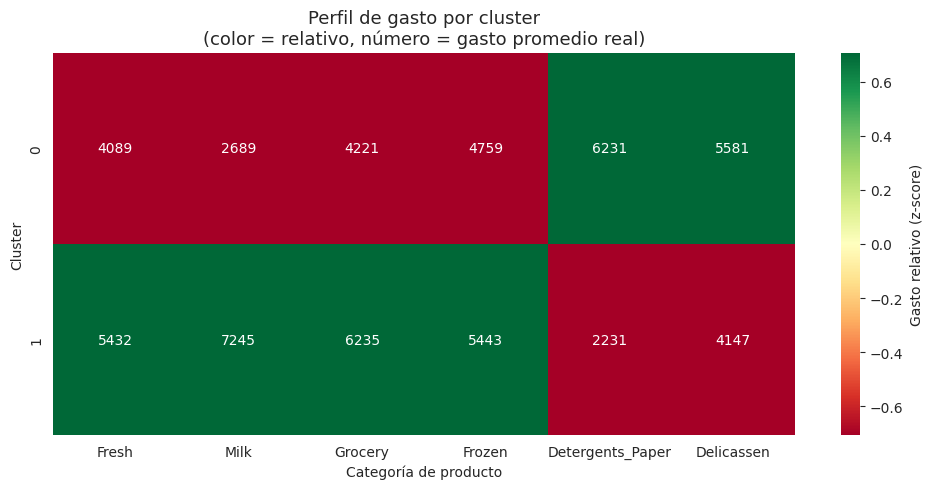

In [24]:
# Heatmap normalizado (z-score por columna)
profile_norm = cluster_profile[spend_cols].apply(
    lambda x: (x - x.mean()) / x.std(), axis=0
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(profile_norm, annot=cluster_profile[spend_cols].values, fmt=".0f",
            cmap="RdYlGn", center=0, ax=ax,
            cbar_kws={"label": "Gasto relativo (z-score)"})
ax.set_title("Perfil de gasto por cluster\n(color = relativo, número = gasto promedio real)",
            fontsize=13)
ax.set_xlabel("Categoría de producto")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()

In [25]:
# Tabla cruzada Cluster × Channel
crosstab = pd.crosstab(df_result["cluster"], df_result["Channel"],
                       margins=True, margins_name="Total")
crosstab.columns = ["Horeca (1)", "Retail (2)", "Total"]
crosstab

,Horeca (1),Retail (2),Total
cluster,,,
0,116,114,230
1,94,96,190
Total,210,210,420


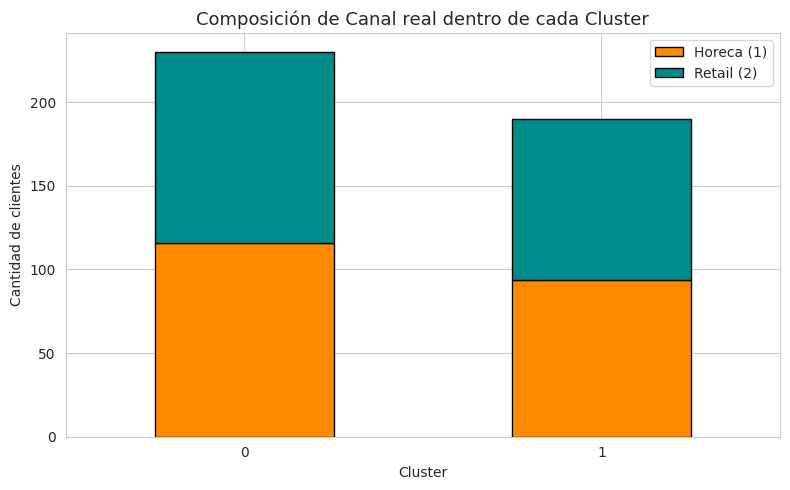

In [26]:
# Gráfico apilado de composición de canal por cluster
crosstab_plot = pd.crosstab(df_result["cluster"], df_result["Channel"])

fig, ax = plt.subplots(figsize=(8, 5))
crosstab_plot.plot(kind="bar", stacked=True, ax=ax,
                    color=["darkorange", "darkcyan"], edgecolor="black")
ax.set_title("Composición de Canal real dentro de cada Cluster", fontsize=13)
ax.set_xlabel("Cluster"); ax.set_ylabel("Cantidad de clientes")
ax.legend(["Horeca (1)", "Retail (2)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. PCA antes de t-SNE

Patrón estándar para acelerar t-SNE en datasets grandes: reducir primero con PCA a un número moderado de componentes.

In [27]:
# PCA reteniendo el 95% de la varianza
pca = PCA(n_components=0.95, random_state=SEED)
X_pca = pca.fit_transform(X)

print(f"Dimensiones originales : {X.shape[1]}")
print(f"Dimensiones tras PCA    : {X_pca.shape[1]}")
print(f"Varianza explicada      : {pca.explained_variance_ratio_.sum():.4f}")

Dimensiones originales : 6
Dimensiones tras PCA    : 6
Varianza explicada      : 1.0000


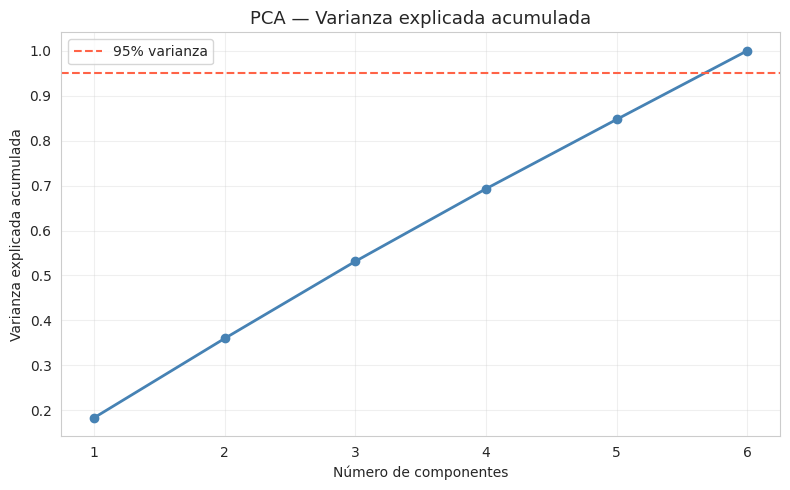

In [28]:
# Curva de varianza explicada acumulada
pca_full = PCA(random_state=SEED).fit(X)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
        np.cumsum(pca_full.explained_variance_ratio_),
        marker="o", color="steelblue", linewidth=2)
ax.axhline(y=0.95, color="tomato", linestyle="--", label="95% varianza")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza explicada acumulada")
ax.set_title("PCA — Varianza explicada acumulada", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Calculando t-SNE sobre componentes PCA...

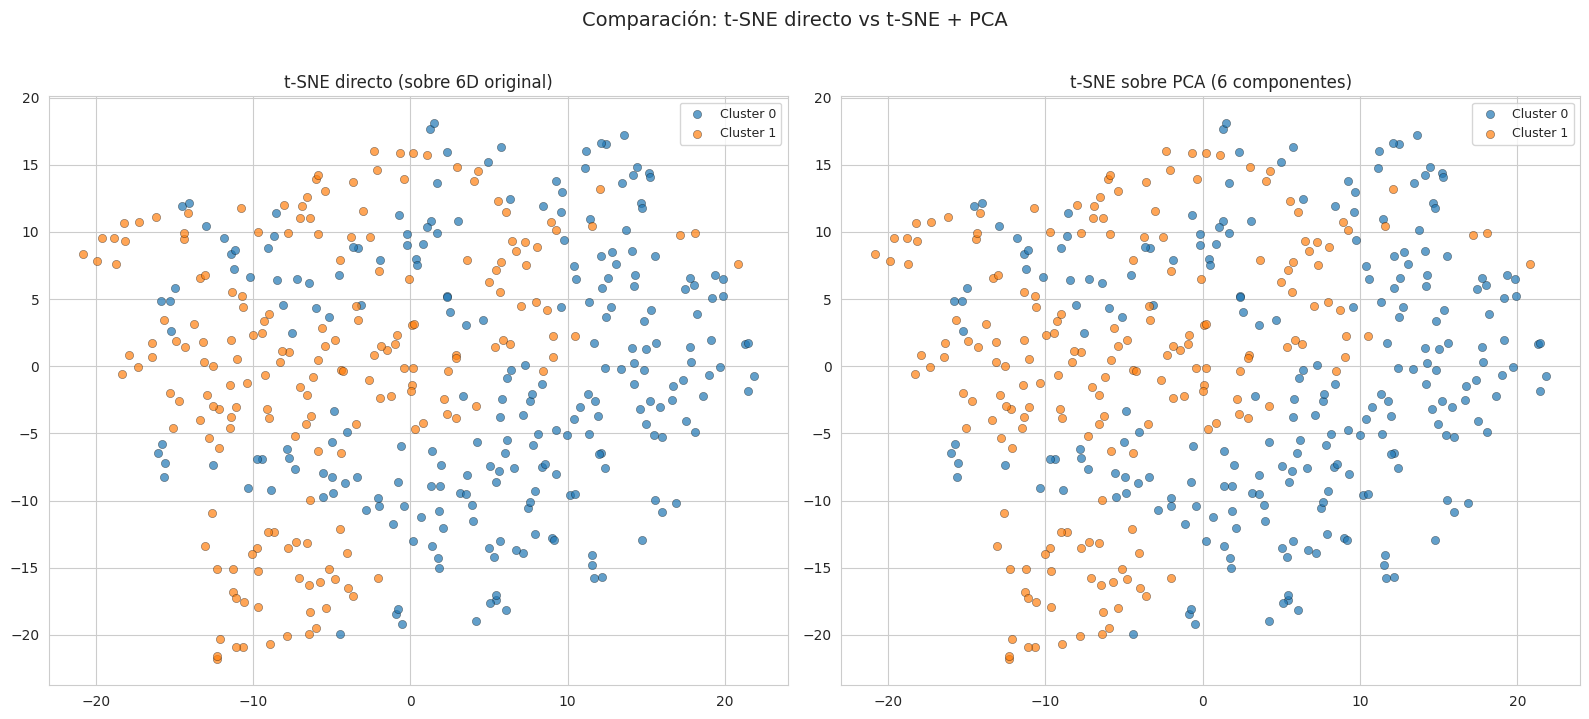

In [29]:
print("Calculando t-SNE sobre componentes PCA...")
tsne_pca = TSNE(
    n_components=2, perplexity=30, learning_rate="auto",
    init="pca", random_state=SEED
)
embedding_pca = tsne_pca.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for cluster_id in sorted(tsne_df["cluster_kmeans"].unique()):
    subset = tsne_df[tsne_df["cluster_kmeans"] == cluster_id]
    axes[0].scatter(subset["tsne_x"], subset["tsne_y"],
                    color=palette[cluster_id], label=f"Cluster {cluster_id}",
                    s=35, alpha=0.7, edgecolor="black", linewidth=0.3)
axes[0].set_title("t-SNE directo (sobre 6D original)", fontsize=12)
axes[0].legend(fontsize=9)

for cluster_id in sorted(tsne_df["cluster_kmeans"].unique()):
    mask_c = labels_kmeans == cluster_id
    axes[1].scatter(embedding_pca[mask_c, 0], embedding_pca[mask_c, 1],
                    color=palette[cluster_id], label=f"Cluster {cluster_id}",
                    s=35, alpha=0.7, edgecolor="black", linewidth=0.3)
axes[1].set_title(f"t-SNE sobre PCA ({X_pca.shape[1]} componentes)", fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle("Comparación: t-SNE directo vs t-SNE + PCA", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 12. Incorporar `Region` como variable categórica (One-Hot Encoding)

Evaluamos el impacto de añadir `Region` codificada con one-hot al vector de features.

In [30]:
from sklearn.preprocessing import OneHotEncoder

# One-Hot Encoding de Region
ohe = OneHotEncoder(sparse_output=False, drop=None)
region_ohe = ohe.fit_transform(df_clean[["Region"]])

# Concatenar features log escaladas + region one-hot escaladas
X_region_raw = np.hstack([df_clean[log_cols].values, region_ohe])
scaler_region = StandardScaler()
X_region = scaler_region.fit_transform(X_region_raw)

print(f"Shape features SIN Region: {X.shape}")
print(f"Shape features CON Region: {X_region.shape}")

# K-Means con el mismo k para comparar
kmeans_region = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10, max_iter=300)
labels_region = kmeans_region.fit_predict(X_region)
silhouette_region = silhouette_score(X_region, labels_region)

print(f"\nSilhouette SIN Region  : {final_silhouette:.4f}")
print(f"Silhouette CON Region  : {silhouette_region:.4f}")
print(f"Diferencia             : {silhouette_region - final_silhouette:+.4f}")

Shape features SIN Region: (420, 6)
Shape features CON Region: (420, 9)

Silhouette SIN Region  : 0.1186
Silhouette CON Region  : 0.1789
Diferencia             : +0.0603


**Lectura:** Si el Silhouette con `Region` es similar o menor, la ubicación geográfica no aporta estructura adicional sobre el patrón de gasto — los segmentos son independientes de la región.

## 13. Bisecting K-Means (alternativa jerárquica divisiva)

Empieza con todos los puntos en un cluster y los va dividiendo en 2 recursivamente. Suele ser más rápido y más determinístico que K-Means estándar, con una estructura jerárquica interpretable.

In [31]:
bkm = BisectingKMeans(n_clusters=K_FINAL, random_state=SEED, n_init=1, max_iter=300)
labels_bkm = bkm.fit_predict(X)

silhouette_bkm = silhouette_score(X, labels_bkm)
inertia_bkm    = bkm.inertia_

print(f"Silhouette K-Means           : {final_silhouette:.4f}")
print(f"Silhouette Bisecting K-Means : {silhouette_bkm:.4f}")
print(f"Inertia Bisecting K-Means    : {inertia_bkm:,.2f}")

print("\nTamaño de clusters (Bisecting):")
print(pd.Series(labels_bkm).value_counts().sort_index().to_string())

Silhouette K-Means           : 0.1186
Silhouette Bisecting K-Means : 0.1135
Inertia Bisecting K-Means    : 2,240.70

Tamaño de clusters (Bisecting):
0    231
1    189


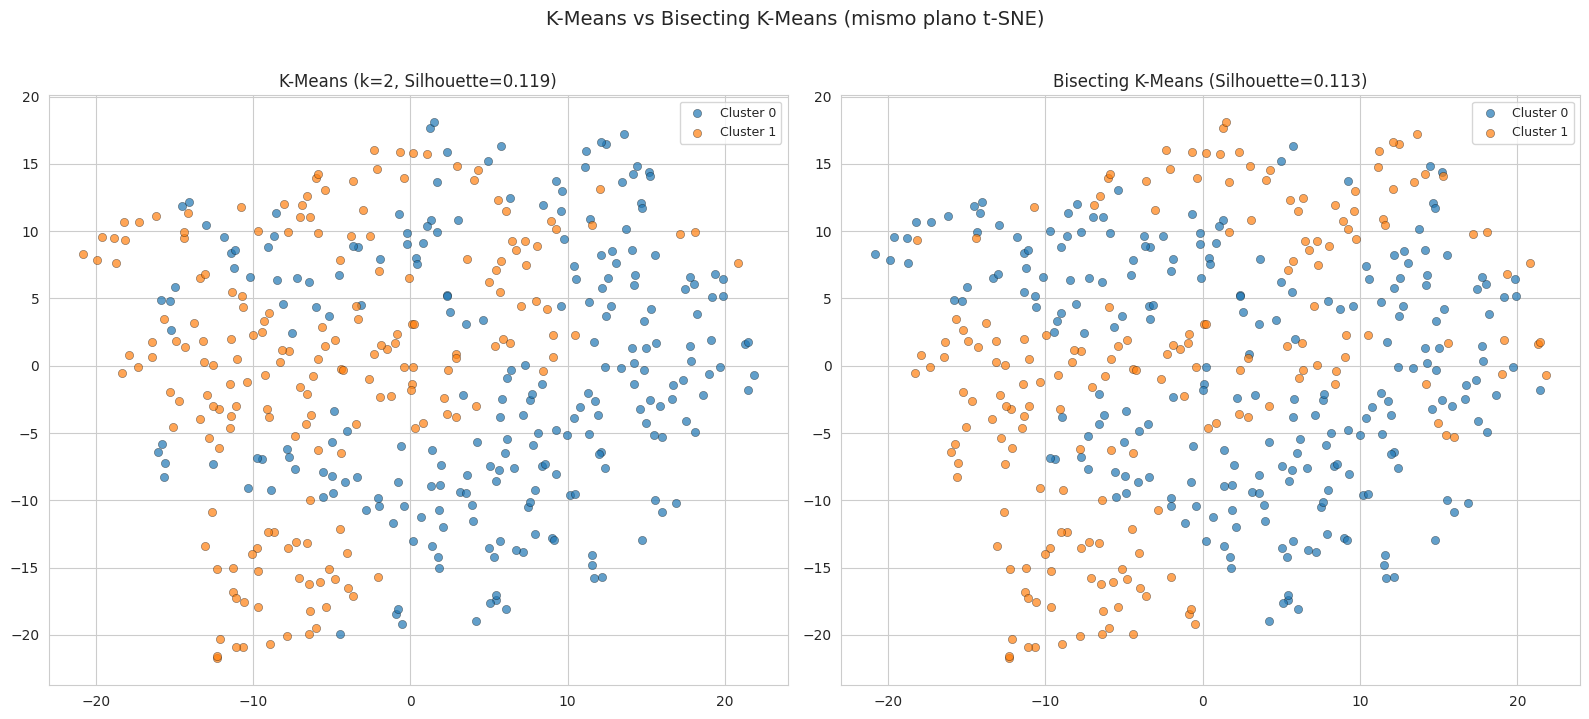

In [32]:
# Comparación visual K-Means vs Bisecting K-Means en el mismo plano t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for cluster_id in sorted(np.unique(labels_kmeans)):
    mask_c = labels_kmeans == cluster_id
    axes[0].scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                    color=palette[cluster_id], label=f"Cluster {cluster_id}",
                    s=35, alpha=0.7, edgecolor="black", linewidth=0.3)
axes[0].set_title(f"K-Means (k={K_FINAL}, Silhouette={final_silhouette:.3f})", fontsize=12)
axes[0].legend(fontsize=9)

for cluster_id in sorted(np.unique(labels_bkm)):
    mask_c = labels_bkm == cluster_id
    axes[1].scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                    color=palette[cluster_id], label=f"Cluster {cluster_id}",
                    s=35, alpha=0.7, edgecolor="black", linewidth=0.3)
axes[1].set_title(f"Bisecting K-Means (Silhouette={silhouette_bkm:.3f})", fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle("K-Means vs Bisecting K-Means (mismo plano t-SNE)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. Gaussian Mixture Models (clusters no esféricos)

K-Means asume clusters esféricos y de tamaño similar. **GMM** modela cada cluster como una gaussiana multivariada con su propia matriz de covarianza (clusters elípticos), y asigna **probabilidades** de pertenencia (soft clustering).

In [33]:
gmm = GaussianMixture(
    n_components=K_FINAL, covariance_type="full",
    random_state=SEED, max_iter=200
)
gmm.fit(X)
labels_gmm  = gmm.predict(X)
proba_gmm   = gmm.predict_proba(X)

silhouette_gmm = silhouette_score(X, labels_gmm)
bic_gmm        = gmm.bic(X)
aic_gmm        = gmm.aic(X)
log_lik_gmm    = gmm.score(X) * len(X)

print(f"Silhouette K-Means : {final_silhouette:.4f}")
print(f"Silhouette GMM     : {silhouette_gmm:.4f}")
print(f"Log-likelihood GMM : {log_lik_gmm:.2f}")
print(f"BIC GMM            : {bic_gmm:.2f}")
print(f"AIC GMM            : {aic_gmm:.2f}")

Silhouette K-Means : 0.1186
Silhouette GMM     : 0.1099
Log-likelihood GMM : -3561.84
BIC GMM            : 7455.90
AIC GMM            : 7233.69


In [34]:
# Inspeccionar probabilidades de pertenencia
proba_df = pd.DataFrame(proba_gmm, columns=[f"P(cluster={i})" for i in range(K_FINAL)])
proba_df["cluster_asignado"] = labels_gmm
proba_df.head(10)

,P(cluster=0),P(cluster=1),cluster_asignado
0,0.341941,0.658059,1
1,0.100695,0.899305,1
2,0.518719,0.481281,0
3,0.126639,0.873361,1
4,0.013886,0.986114,1
5,0.741126,0.258874,0
6,0.662779,0.337221,0
7,0.959757,0.040243,0
8,0.089349,0.910651,1
9,0.331451,0.668549,1


**Lectura de las probabilidades:** clientes con probabilidad ~0.5/0.5 son *fronterizos* entre segmentos — información valiosa que K-Means descarta al forzar asignación dura.

## 15. BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)

**BIRCH** es un algoritmo diseñado específicamente para **datasets muy grandes**. Construye incrementalmente un árbol de resúmenes (CF-tree = Clustering Feature tree) en una sola pasada, lo que lo hace especialmente eficiente en memoria y tiempo cuando `n` es grande.

**Características clave:**
- **Escalable**: procesa los datos en una sola pasada (streaming-friendly).
- **Jerárquico + particional**: construye un árbol y luego opcionalmente aplica otro clustering (por ejemplo, agglomerative) sobre los sub-clusters resultantes.
- **Dos hiperparámetros importantes**:
  - `threshold`: radio máximo de un sub-cluster. **Menor** ⇒ más sub-clusters, mayor granularidad.
  - `branching_factor`: número máximo de sub-clusters por nodo del árbol.
- **Compara favorablemente con K-Means** en tiempo cuando el dataset no cabe en memoria.

**Limitaciones:**
- Sólo funciona bien con features numéricas.
- Sensible al orden de los datos.
- Asume clusters aproximadamente esféricos (usa distancia euclidiana).

In [35]:
# BIRCH con n_clusters=K_FINAL — hace clustering global tras construir el árbol.
birch = Birch(
    n_clusters=K_FINAL,
    threshold=0.5,          # radio máximo de sub-cluster (default)
    branching_factor=50     # default
)
labels_birch = birch.fit_predict(X)

silhouette_birch = silhouette_score(X, labels_birch)
n_subclusters    = len(birch.subcluster_centers_)

print(f"Silhouette BIRCH        : {silhouette_birch:.4f}")
print(f"Sub-clusters generados  : {n_subclusters} (sub-clusters del CF-tree)")
print(f"Clusters finales        : {len(np.unique(labels_birch))}")
print(f"\nTamaño de clusters (BIRCH):")
print(pd.Series(labels_birch).value_counts().sort_index().to_string())

Silhouette BIRCH        : 0.0956
Sub-clusters generados  : 358 (sub-clusters del CF-tree)
Clusters finales        : 2

Tamaño de clusters (BIRCH):
0    290
1    130


In [36]:
# Efecto del threshold — parámetro más importante de BIRCH
print("Efecto del parámetro threshold sobre BIRCH:\n")
thresholds = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
birch_results = []
for th in thresholds:
    b = Birch(n_clusters=K_FINAL, threshold=th, branching_factor=50)
    lab = b.fit_predict(X)
    sil = silhouette_score(X, lab) if len(np.unique(lab)) > 1 else np.nan
    birch_results.append({
        "threshold": th,
        "sub_clusters": len(b.subcluster_centers_),
        "silhouette": round(sil, 4)
    })
    print(f"  threshold={th:<5}  sub-clusters={len(b.subcluster_centers_):>3}  "
          f"silhouette={sil:.4f}")

birch_tuning = pd.DataFrame(birch_results)

Efecto del parámetro threshold sobre BIRCH:

  threshold=0.1    sub-clusters=420  silhouette=0.0886
  threshold=0.3    sub-clusters=418  silhouette=0.0883
  threshold=0.5    sub-clusters=358  silhouette=0.0956
  threshold=0.7    sub-clusters=268  silhouette=0.0823
  threshold=1.0    sub-clusters=157  silhouette=0.0626
  threshold=1.5    sub-clusters= 49  silhouette=0.1770
  threshold=2.0    sub-clusters= 13  silhouette=0.1135


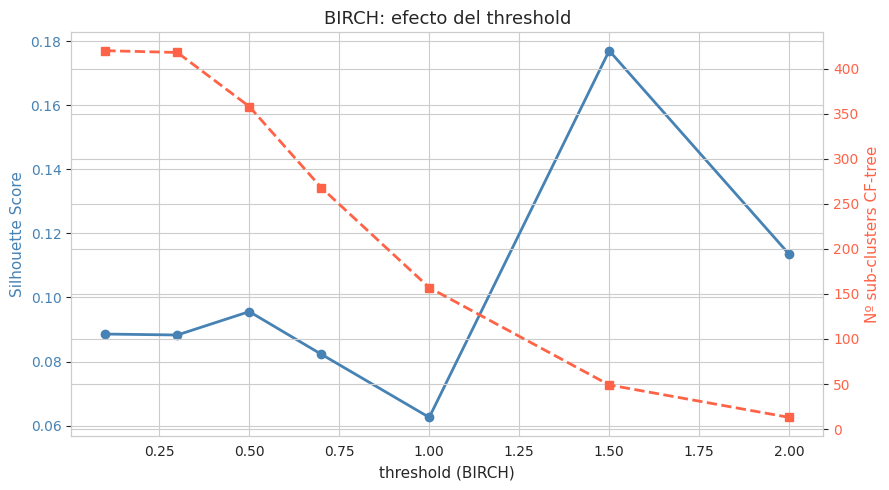

In [37]:
# Curva threshold vs silhouette y sub-clusters generados
fig, ax1 = plt.subplots(figsize=(9, 5))

color1 = "steelblue"
ax1.plot(birch_tuning["threshold"], birch_tuning["silhouette"],
         marker="o", color=color1, linewidth=2, label="Silhouette")
ax1.set_xlabel("threshold (BIRCH)", fontsize=11)
ax1.set_ylabel("Silhouette Score", color=color1, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tomato"
ax2.plot(birch_tuning["threshold"], birch_tuning["sub_clusters"],
         marker="s", color=color2, linewidth=2, linestyle="--",
         label="Sub-clusters")
ax2.set_ylabel("Nº sub-clusters CF-tree", color=color2, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("BIRCH: efecto del threshold", fontsize=13)
fig.tight_layout()
plt.show()

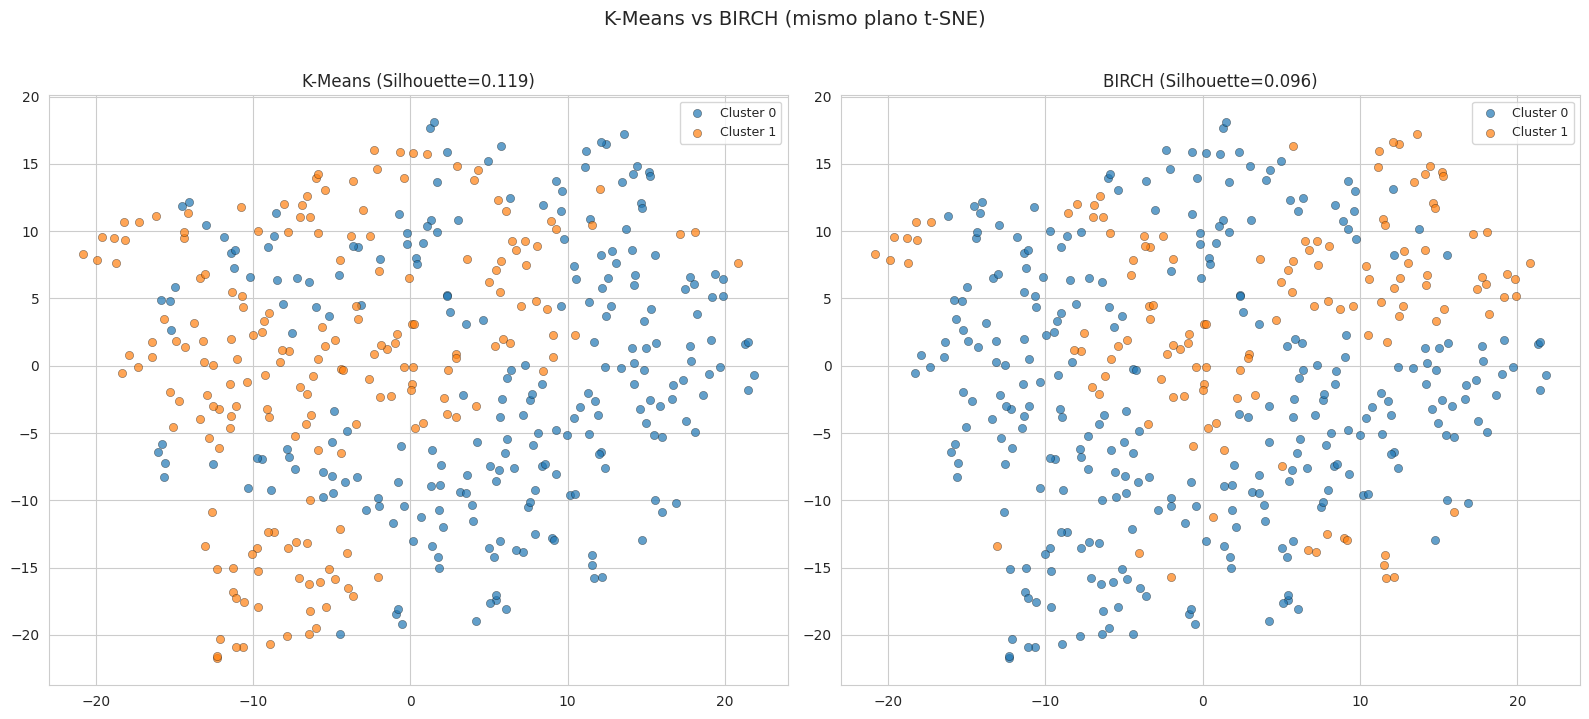

In [38]:
# Visualización BIRCH en el plano t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for cluster_id in sorted(np.unique(labels_kmeans)):
    mask_c = labels_kmeans == cluster_id
    axes[0].scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                    color=palette[cluster_id], label=f"Cluster {cluster_id}",
                    s=35, alpha=0.7, edgecolor="black", linewidth=0.3)
axes[0].set_title(f"K-Means (Silhouette={final_silhouette:.3f})", fontsize=12)
axes[0].legend(fontsize=9)

birch_palette = sns.color_palette("tab10", n_colors=len(np.unique(labels_birch)))
for cluster_id in sorted(np.unique(labels_birch)):
    mask_c = labels_birch == cluster_id
    axes[1].scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                    color=birch_palette[cluster_id], label=f"Cluster {cluster_id}",
                    s=35, alpha=0.7, edgecolor="black", linewidth=0.3)
axes[1].set_title(f"BIRCH (Silhouette={silhouette_birch:.3f})", fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle("K-Means vs BIRCH (mismo plano t-SNE)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 16. Agglomerative Hierarchical Clustering

Enfoque jerárquico **aglomerativo**: parte de cada punto como su propio cluster y los va fusionando por proximidad hasta llegar a `k` clusters. Usa distintos criterios de enlace (`linkage`):

- **ward** — minimiza la varianza intra-cluster (equivalente jerárquico a K-Means).
- **average** — distancia promedio entre pares.
- **complete** — distancia máxima (diámetro).
- **single** — distancia mínima (tiende a "chaining", crea clusters alargados).

In [39]:
linkages = ["ward", "average", "complete", "single"]
agglo_results = {}

for link in linkages:
    ag = AgglomerativeClustering(n_clusters=K_FINAL, linkage=link)
    lab = ag.fit_predict(X)
    sil = silhouette_score(X, lab)
    agglo_results[link] = {"labels": lab, "silhouette": sil}
    print(f"  linkage={link:<10}  →  Silhouette = {sil:.4f}")

# Elegimos el mejor
best_link = max(agglo_results, key=lambda k: agglo_results[k]["silhouette"])
labels_agglo    = agglo_results[best_link]["labels"]
silhouette_agglo = agglo_results[best_link]["silhouette"]

print(f"\nMejor linkage: {best_link} (Silhouette={silhouette_agglo:.4f})")

  linkage=ward        →  Silhouette = 0.0886
  linkage=average     →  Silhouette = 0.2935
  linkage=complete    →  Silhouette = 0.0529
  linkage=single      →  Silhouette = 0.2935

Mejor linkage: average (Silhouette=0.2935)


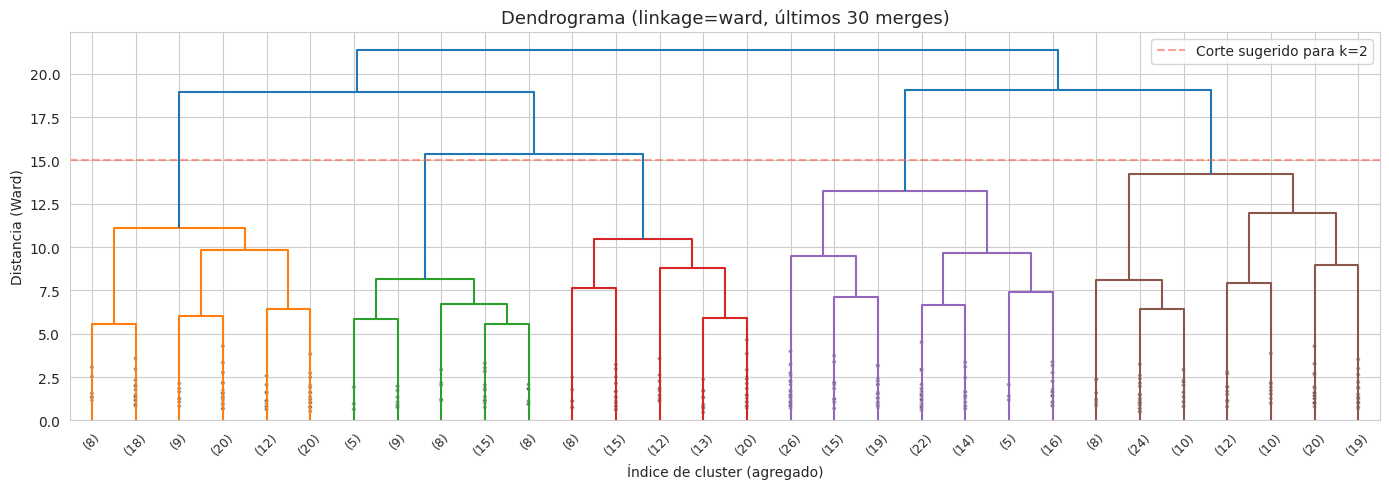

In [40]:
# Dendrograma para elegir k visualmente
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

Z = scipy_linkage(X, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=45,
           leaf_font_size=9, show_contracted=True)
ax.set_title("Dendrograma (linkage=ward, últimos 30 merges)", fontsize=13)
ax.set_xlabel("Índice de cluster (agregado)")
ax.set_ylabel("Distancia (Ward)")
ax.axhline(y=15, color="tomato", linestyle="--", alpha=0.6,
           label="Corte sugerido para k=2")
ax.legend()
plt.tight_layout()
plt.show()

## 17. DBSCAN y HDBSCAN (clustering basado en densidad)

**DBSCAN** encuentra clusters como regiones densas de puntos, sin requerir `k` a priori. Puntos aislados los marca como **ruido** (`-1`), útil para detección de outliers.

Parámetros clave:
- `eps` — radio de vecindad.
- `min_samples` — nº mínimo de puntos para considerar un núcleo.

**HDBSCAN** es la versión jerárquica y adaptativa (no requiere `eps` fijo).

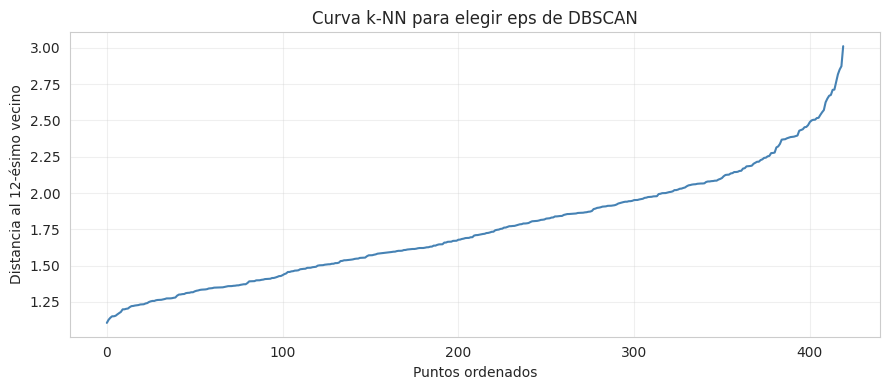

In [41]:
# --- DBSCAN ---
# Estimamos eps con la distancia al k-ésimo vecino (heurística del "codo")
from sklearn.neighbors import NearestNeighbors

k_nn = 2 * X.shape[1]  # regla heurística
nn = NearestNeighbors(n_neighbors=k_nn).fit(X)
distances, _ = nn.kneighbors(X)
distances_sorted = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(distances_sorted, color="steelblue")
ax.set_xlabel("Puntos ordenados")
ax.set_ylabel(f"Distancia al {k_nn}-ésimo vecino")
ax.set_title("Curva k-NN para elegir eps de DBSCAN", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# Prueba de varios eps
print("DBSCAN con distintos eps:\n")
for eps_try in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    db = DBSCAN(eps=eps_try, min_samples=k_nn)
    lab = db.fit_predict(X)
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise    = (lab == -1).sum()
    sil = (silhouette_score(X[lab != -1], lab[lab != -1])
           if n_clusters > 1 and (lab != -1).sum() > n_clusters else np.nan)
    print(f"  eps={eps_try}  →  clusters={n_clusters}  ruido={n_noise:>3}  "
          f"silhouette={sil:.4f}" if not np.isnan(sil)
          else f"  eps={eps_try}  →  clusters={n_clusters}  ruido={n_noise:>3}  silhouette=N/A")

DBSCAN con distintos eps:

  eps=0.5  →  clusters=0  ruido=420  silhouette=N/A
  eps=0.8  →  clusters=0  ruido=420  silhouette=N/A
  eps=1.0  →  clusters=0  ruido=420  silhouette=N/A
  eps=1.2  →  clusters=2  ruido=334  silhouette=0.1257
  eps=1.5  →  clusters=1  ruido=162  silhouette=N/A
  eps=2.0  →  clusters=1  ruido= 12  silhouette=N/A


In [43]:
# Elegimos el eps que dio el mejor silhouette en el barrido de arriba.
# En este dataset (ya limpio por IQR + log-scaling), los métodos por
# densidad requieren un eps relativamente amplio para no clasificar
# casi todo como ruido — un hallazgo pedagógicamente relevante.
DBSCAN_EPS = 1.2
db = DBSCAN(eps=DBSCAN_EPS, min_samples=k_nn)
labels_dbscan = db.fit_predict(X)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db    = (labels_dbscan == -1).sum()

if n_clusters_db > 1:
    mask_valid = labels_dbscan != -1
    silhouette_dbscan = silhouette_score(X[mask_valid], labels_dbscan[mask_valid])
else:
    silhouette_dbscan = np.nan

print(f"DBSCAN (eps={DBSCAN_EPS})")
print(f"  Clusters encontrados : {n_clusters_db}")
print(f"  Puntos de ruido      : {n_noise_db} ({n_noise_db/len(X)*100:.1f}%)")
print(f"  Silhouette (excluyendo ruido): {silhouette_dbscan:.4f}")

DBSCAN (eps=1.2)
  Clusters encontrados : 2
  Puntos de ruido      : 334 (79.5%)
  Silhouette (excluyendo ruido): 0.1257


In [44]:
# --- HDBSCAN ---
# Nota: HDBSCAN no requiere `eps`, pero sí `min_cluster_size`. En un
# dataset compacto como este, un valor pequeño (5-10) permite descubrir
# sub-estructura sin que todo colapse en ruido.
if HDBSCAN is not None:
    hdb = HDBSCAN(min_cluster_size=10, min_samples=3)
    labels_hdbscan = hdb.fit_predict(X)

    n_clusters_hdb = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
    n_noise_hdb    = (labels_hdbscan == -1).sum()

    if n_clusters_hdb > 1:
        mask_valid = labels_hdbscan != -1
        silhouette_hdbscan = silhouette_score(X[mask_valid], labels_hdbscan[mask_valid])
    else:
        silhouette_hdbscan = np.nan

    print(f"HDBSCAN ({HDBSCAN_SOURCE})")
    print(f"  Clusters encontrados : {n_clusters_hdb}")
    print(f"  Puntos de ruido      : {n_noise_hdb} ({n_noise_hdb/len(X)*100:.1f}%)")
    print(f"  Silhouette (excluyendo ruido): {silhouette_hdbscan:.4f}")
else:
    labels_hdbscan     = None
    silhouette_hdbscan = np.nan
    n_clusters_hdb     = 0
    n_noise_hdb        = 0
    print("HDBSCAN no disponible — instala con `pip install hdbscan` o actualiza sklearn>=1.3")

HDBSCAN (sklearn.cluster.HDBSCAN)
  Clusters encontrados : 2
  Puntos de ruido      : 368 (87.6%)
  Silhouette (excluyendo ruido): 0.1389


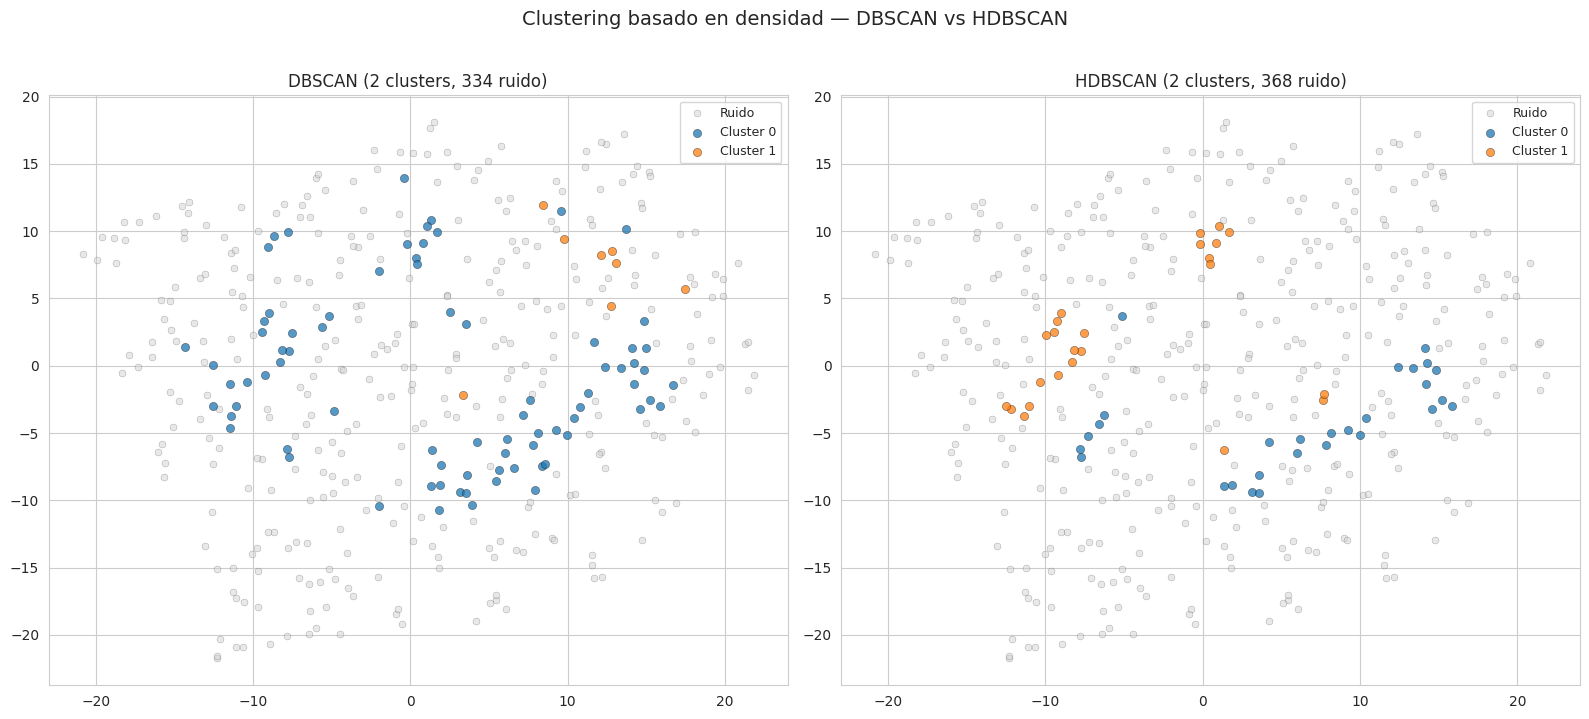

In [45]:
# Visualizar DBSCAN y HDBSCAN en el plano t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# DBSCAN
unique_lab = sorted(set(labels_dbscan))
db_palette = sns.color_palette("tab10", n_colors=max(1, n_clusters_db))
for lab in unique_lab:
    mask_c = labels_dbscan == lab
    if lab == -1:
        axes[0].scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                        color="lightgrey", label="Ruido",
                        s=25, alpha=0.5, edgecolor="black", linewidth=0.2)
    else:
        axes[0].scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                        color=db_palette[lab % len(db_palette)],
                        label=f"Cluster {lab}",
                        s=35, alpha=0.75, edgecolor="black", linewidth=0.3)
axes[0].set_title(f"DBSCAN ({n_clusters_db} clusters, {n_noise_db} ruido)", fontsize=12)
axes[0].legend(fontsize=9)

# HDBSCAN
if labels_hdbscan is not None:
    unique_lab_h = sorted(set(labels_hdbscan))
    hdb_palette = sns.color_palette("tab10", n_colors=max(1, n_clusters_hdb))
    for lab in unique_lab_h:
        mask_c = labels_hdbscan == lab
        if lab == -1:
            axes[1].scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                            color="lightgrey", label="Ruido",
                            s=25, alpha=0.5, edgecolor="black", linewidth=0.2)
        else:
            axes[1].scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                            color=hdb_palette[lab % len(hdb_palette)],
                            label=f"Cluster {lab}",
                            s=35, alpha=0.75, edgecolor="black", linewidth=0.3)
    axes[1].set_title(f"HDBSCAN ({n_clusters_hdb} clusters, {n_noise_hdb} ruido)", fontsize=12)
    axes[1].legend(fontsize=9)
else:
    axes[1].text(0.5, 0.5, "HDBSCAN no disponible",
                 transform=axes[1].transAxes, ha="center", fontsize=12)

plt.suptitle("Clustering basado en densidad — DBSCAN vs HDBSCAN",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 18. Mean Shift y Spectral Clustering

- **Mean Shift**: encuentra los modos de la densidad; no requiere `k`. Sensible al `bandwidth`.
- **Spectral Clustering**: usa los autovectores de la matriz de afinidad (kernel gaussiano); bueno para clusters no convexos, pero costoso computacionalmente.

In [46]:
# --- Mean Shift ---
# quantile más bajo => bandwidth más estrecho => más clusters descubiertos.
# 0.2 tiende a devolver 1 cluster en este dataset compacto; usamos 0.1.
bandwidth = estimate_bandwidth(X, quantile=0.1, random_state=SEED)
ms = MeanShift(bandwidth=bandwidth)
labels_meanshift = ms.fit_predict(X)

n_clusters_ms = len(np.unique(labels_meanshift))
if n_clusters_ms > 1:
    silhouette_ms = silhouette_score(X, labels_meanshift)
else:
    silhouette_ms = np.nan

print(f"Mean Shift (bandwidth={bandwidth:.3f})")
print(f"  Clusters encontrados : {n_clusters_ms}")
print(f"  Silhouette           : {silhouette_ms:.4f}" if not np.isnan(silhouette_ms) else "  Silhouette: N/A")

Mean Shift (bandwidth=2.235)
  Clusters encontrados : 2
  Silhouette           : 0.1901


In [47]:
# --- Spectral Clustering ---
sc = SpectralClustering(
    n_clusters=K_FINAL, affinity="rbf", gamma=1.0,
    random_state=SEED, assign_labels="kmeans"
)
labels_spectral = sc.fit_predict(X)
silhouette_spectral = silhouette_score(X, labels_spectral)

print(f"Spectral Clustering (k={K_FINAL}, RBF)")
print(f"  Silhouette : {silhouette_spectral:.4f}")

Spectral Clustering (k=2, RBF)
  Silhouette : 0.2238


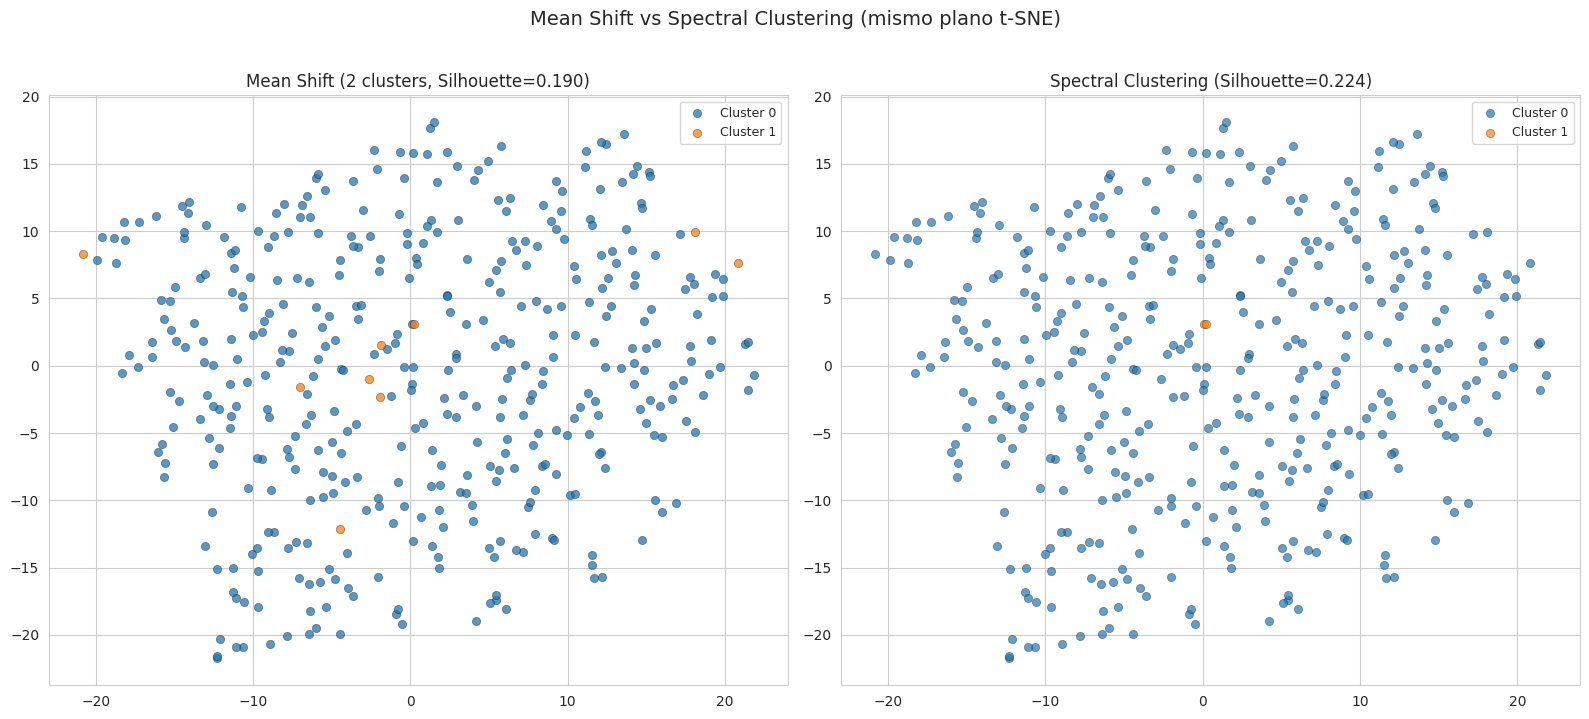

In [48]:
# Visualizar Mean Shift y Spectral en el plano t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ms_palette = sns.color_palette("tab10", n_colors=max(1, n_clusters_ms))
for cluster_id in sorted(np.unique(labels_meanshift)):
    mask_c = labels_meanshift == cluster_id
    axes[0].scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                    color=ms_palette[cluster_id % len(ms_palette)],
                    label=f"Cluster {cluster_id}",
                    s=35, alpha=0.75, edgecolor="black", linewidth=0.3)
axes[0].set_title(f"Mean Shift ({n_clusters_ms} clusters, "
                  f"Silhouette={silhouette_ms:.3f})" if not np.isnan(silhouette_ms)
                  else f"Mean Shift ({n_clusters_ms} clusters)", fontsize=12)
axes[0].legend(fontsize=9)

for cluster_id in sorted(np.unique(labels_spectral)):
    mask_c = labels_spectral == cluster_id
    axes[1].scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                    color=palette[cluster_id], label=f"Cluster {cluster_id}",
                    s=35, alpha=0.7, edgecolor="black", linewidth=0.3)
axes[1].set_title(f"Spectral Clustering (Silhouette={silhouette_spectral:.3f})",
                  fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle("Mean Shift vs Spectral Clustering (mismo plano t-SNE)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 19. Comparación global de algoritmos

Consolidamos todas las etiquetas obtenidas y las visualizamos lado a lado sobre el mismo plano t-SNE.

In [49]:
all_labels = {
    "K-Means":            labels_kmeans,
    "Bisecting K-Means":  labels_bkm,
    "GMM":                labels_gmm,
    "BIRCH":              labels_birch,
    "Agglomerative":      labels_agglo,
    "DBSCAN":             labels_dbscan,
    "Mean Shift":         labels_meanshift,
    "Spectral":           labels_spectral,
}
if labels_hdbscan is not None:
    all_labels["HDBSCAN"] = labels_hdbscan

print("Etiquetas guardadas de:", list(all_labels.keys()))

Etiquetas guardadas de: ['K-Means', 'Bisecting K-Means', 'GMM', 'BIRCH', 'Agglomerative', 'DBSCAN', 'Mean Shift', 'Spectral', 'HDBSCAN']


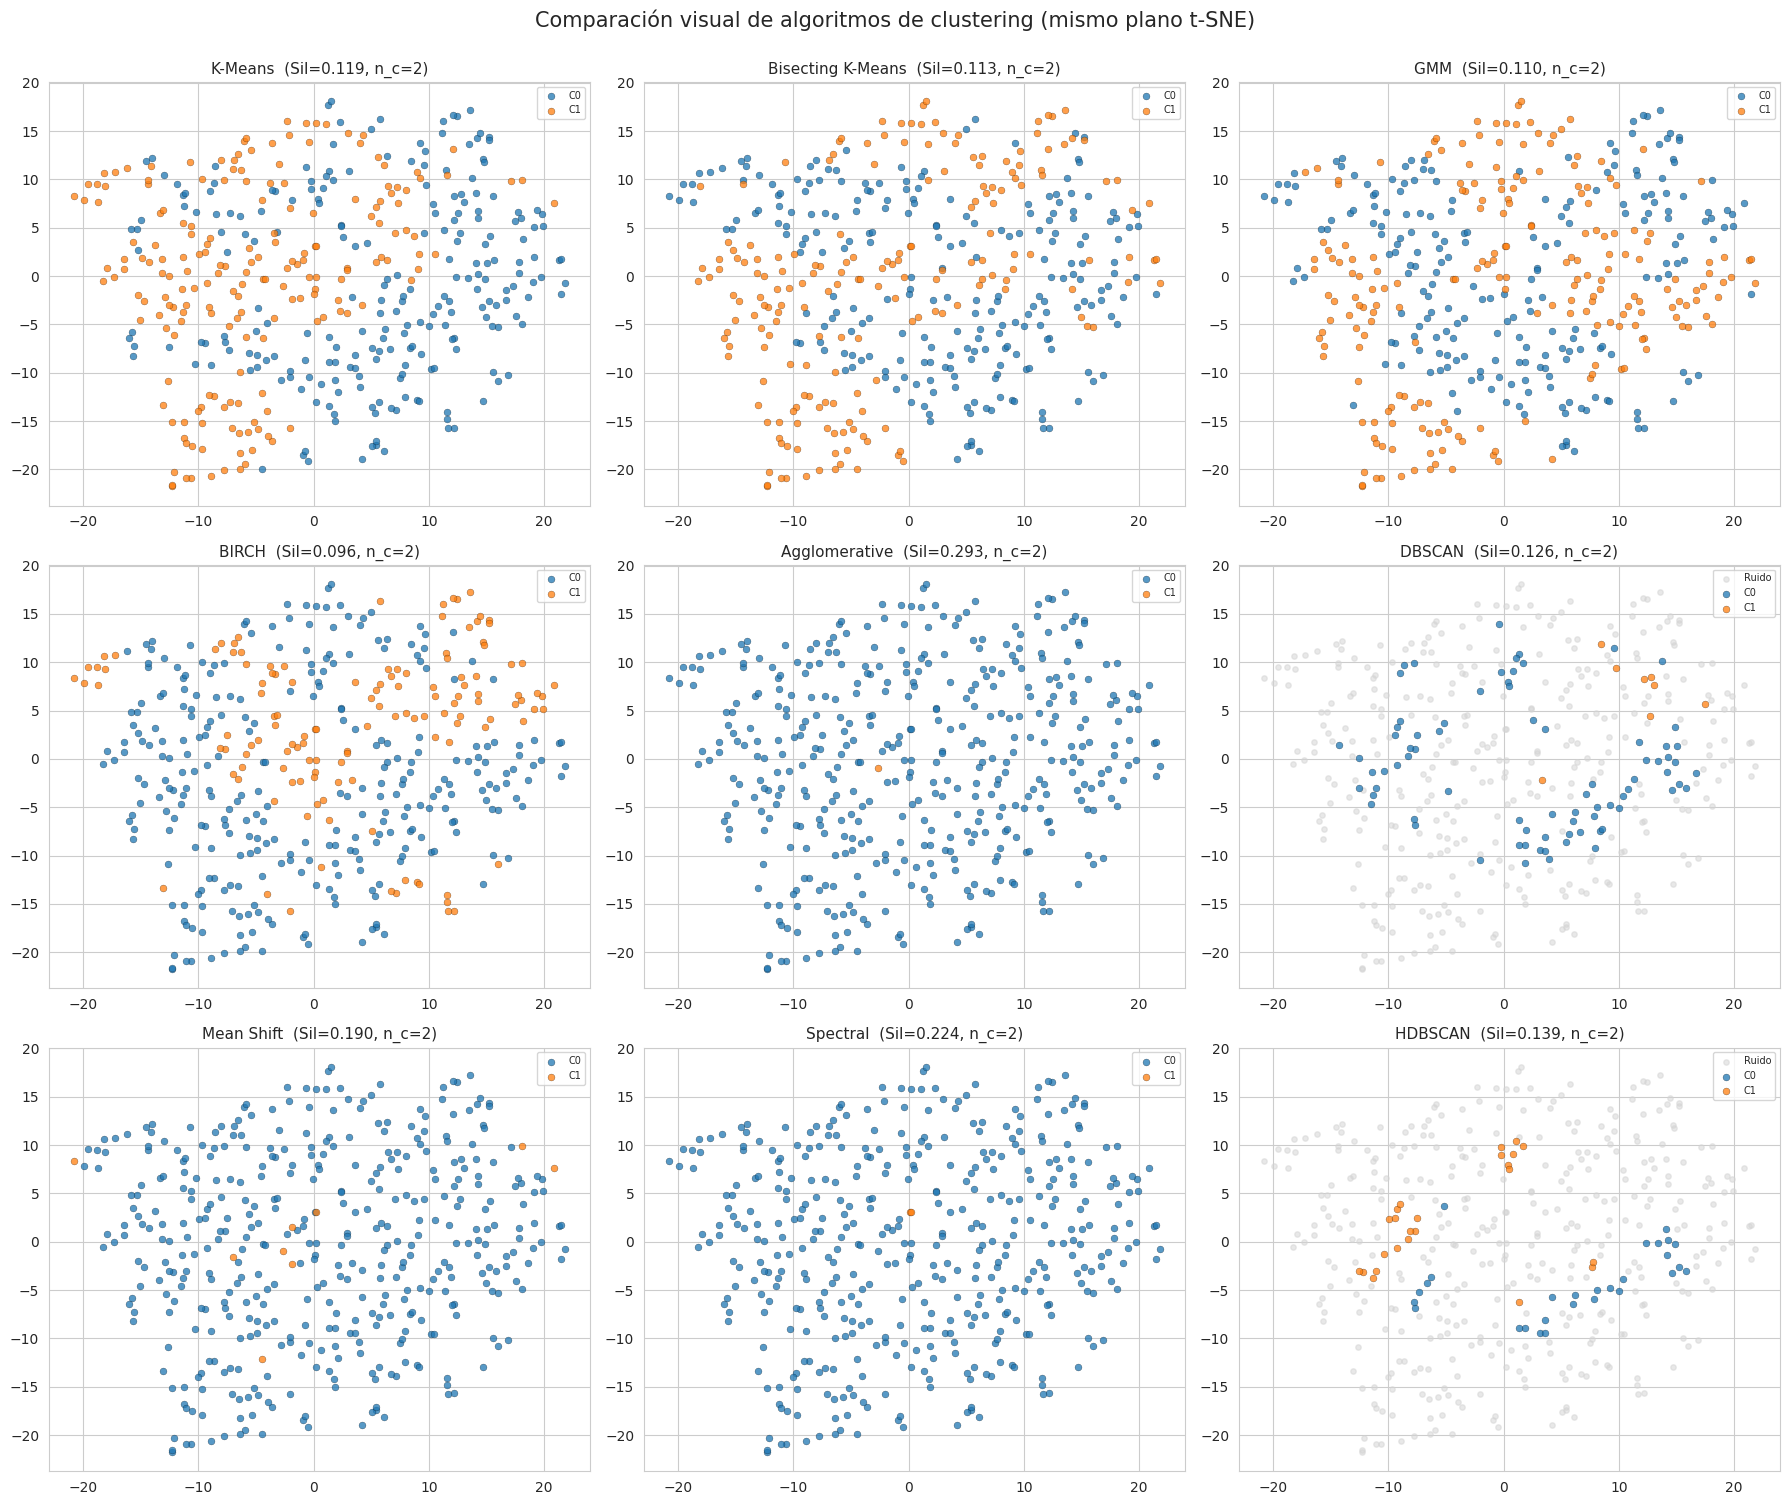

In [50]:
# Grid de visualización — todos los algoritmos sobre t-SNE
n_algos = len(all_labels)
n_cols = 3
n_rows = (n_algos + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for idx, (name, lab) in enumerate(all_labels.items()):
    ax = axes[idx]
    unique_ids = sorted(set(lab))
    n_c = len(unique_ids) - (1 if -1 in unique_ids else 0)
    pal = sns.color_palette("tab10", n_colors=max(1, n_c))
    for cid in unique_ids:
        mask_c = lab == cid
        if cid == -1:
            ax.scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                       color="lightgrey", s=15, alpha=0.5, label="Ruido")
        else:
            ax.scatter(embedding[mask_c, 0], embedding[mask_c, 1],
                       color=pal[cid % len(pal)], s=25, alpha=0.75,
                       edgecolor="black", linewidth=0.2, label=f"C{cid}")

    if len(unique_ids) - (1 if -1 in unique_ids else 0) > 1:
        try:
            valid_mask = lab != -1
            if valid_mask.sum() >= 2 and len(set(lab[valid_mask])) >= 2:
                sil = silhouette_score(X[valid_mask], lab[valid_mask])
                title = f"{name}  (Sil={sil:.3f}, n_c={n_c})"
            else:
                title = f"{name}  (n_c={n_c})"
        except Exception:
            title = f"{name}  (n_c={n_c})"
    else:
        title = f"{name}  (n_c={n_c})"
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7, loc="best")

# Ocultar ejes sobrantes
for j in range(len(all_labels), len(axes)):
    axes[j].axis("off")

plt.suptitle("Comparación visual de algoritmos de clustering (mismo plano t-SNE)",
             fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

## 20. Métricas de evaluación de clustering (más allá de Silhouette)

Silhouette es la métrica más popular, pero **no es la única** ni siempre la mejor. Se agrupan en dos familias:

### 20.1 Métricas **INTERNAS** (no requieren ground truth)
Miden la calidad geométrica del clustering: compacidad intra-cluster y separación entre clusters.

| Métrica | Fórmula intuitiva | Rango | Interpretación |
|---|---|---|---|
| **Silhouette** `s(i) = (b − a) / max(a,b)` | Compara distancia media al propio cluster (a) vs al vecino más cercano (b) | [−1, 1] | Mayor es mejor. Cerca de 1: bien asignado; ~0: en la frontera; < 0: mal asignado. |
| **Calinski-Harabasz** (Variance Ratio Criterion) | Razón entre dispersión inter-cluster y intra-cluster | [0, ∞) | **Mayor es mejor**. Favorece clusters densos y bien separados. Rápido. |
| **Davies-Bouldin** | Promedio de la razón (dispersión intra) / (distancia entre centroides) para el par más "confuso" | [0, ∞) | **Menor es mejor**. 0 sería el ideal. |
| **Dunn Index** | Razón entre la mínima distancia inter-cluster y el máximo diámetro intra-cluster | [0, ∞) | Mayor es mejor. Muy exigente; sensible a outliers. |
| **Inertia / WCSS** | Suma de distancias cuadradas al centroide | [0, ∞) | Menor es mejor. Base del método del codo. Sesga hacia k grande. |

### 20.2 Métricas **EXTERNAS** (requieren ground truth: aquí `Channel`)
Comparan las etiquetas del clustering con etiquetas verdaderas conocidas.

| Métrica | Rango | Interpretación |
|---|---|---|
| **Adjusted Rand Index (ARI)** | [−1, 1] | Mayor es mejor. 1 = coincidencia perfecta, 0 = azar, negativo = peor que azar. |
| **Adjusted Mutual Information (AMI)** | [0, 1] | Mayor es mejor. Corrige el sesgo del MI para número aleatorio de clusters. |
| **Homogeneity** | [0, 1] | Cada cluster contiene sólo miembros de una clase. |
| **Completeness** | [0, 1] | Todos los miembros de una clase están en el mismo cluster. |
| **V-measure** | [0, 1] | Media armónica entre homogeneidad y completitud (análoga al F1). |
| **Fowlkes-Mallows Index (FMI)** | [0, 1] | Media geométrica de precisión y recall sobre pares. |
| **Normalized Mutual Information (NMI)** | [0, 1] | MI normalizado por entropías. |

---

Vamos a calcular todas estas métricas para cada algoritmo.

### 20.3 Implementación del Dunn Index (no viene en sklearn)

In [51]:
def dunn_index(X, labels):
    """
    Dunn Index = min_inter_cluster_distance / max_intra_cluster_diameter

    Mayor es mejor. Requiere >= 2 clusters. Ignora el label -1 (ruido).
    """
    unique_labels = [l for l in np.unique(labels) if l != -1]
    if len(unique_labels) < 2:
        return np.nan

    # Diámetro máximo intra-cluster
    max_intra = 0.0
    for lab in unique_labels:
        pts = X[labels == lab]
        if len(pts) < 2:
            continue
        # Diámetro = máxima distancia entre dos puntos del cluster
        # Para eficiencia, en clusters grandes se puede muestrear
        from scipy.spatial.distance import pdist
        diam = pdist(pts).max() if len(pts) > 1 else 0.0
        max_intra = max(max_intra, diam)

    if max_intra == 0:
        return np.nan

    # Mínima distancia inter-cluster (entre puntos de distintos clusters)
    from scipy.spatial.distance import cdist
    min_inter = np.inf
    for i, lab_i in enumerate(unique_labels):
        for lab_j in unique_labels[i+1:]:
            pts_i = X[labels == lab_i]
            pts_j = X[labels == lab_j]
            d = cdist(pts_i, pts_j).min()
            min_inter = min(min_inter, d)

    return min_inter / max_intra

### 20.4 Cálculo de todas las métricas para cada algoritmo

In [52]:
channel_truth = df_clean["Channel"].values  # ground truth

def evaluate_algorithm(name, labels, X, truth):
    """
    Calcula todas las métricas internas + externas para un algoritmo.
    Métricas internas se calculan excluyendo puntos de ruido (label = -1).
    Métricas externas se calculan con las etiquetas completas (incluyendo -1 como una "clase").
    """
    result = {"Algoritmo": name}
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = int((labels == -1).sum())
    result["n_clusters"] = n_clusters
    result["n_ruido"]    = n_noise

    # Máscara para métricas internas (sin ruido)
    mask = labels != -1
    lab_clean = labels[mask]
    X_clean   = X[mask]

    # --- Métricas INTERNAS ---
    if n_clusters >= 2 and len(set(lab_clean)) >= 2:
        try:
            result["Silhouette"]        = silhouette_score(X_clean, lab_clean)
        except Exception:
            result["Silhouette"] = np.nan
        try:
            result["Calinski-Harabasz"] = calinski_harabasz_score(X_clean, lab_clean)
        except Exception:
            result["Calinski-Harabasz"] = np.nan
        try:
            result["Davies-Bouldin"]    = davies_bouldin_score(X_clean, lab_clean)
        except Exception:
            result["Davies-Bouldin"] = np.nan
        try:
            result["Dunn Index"]        = dunn_index(X_clean, lab_clean)
        except Exception:
            result["Dunn Index"] = np.nan
    else:
        result["Silhouette"]        = np.nan
        result["Calinski-Harabasz"] = np.nan
        result["Davies-Bouldin"]    = np.nan
        result["Dunn Index"]        = np.nan

    # --- Métricas EXTERNAS (contra Channel) ---
    result["ARI"]           = adjusted_rand_score(truth, labels)
    result["AMI"]           = adjusted_mutual_info_score(truth, labels)
    result["NMI"]           = normalized_mutual_info_score(truth, labels)
    result["Homogeneity"]   = homogeneity_score(truth, labels)
    result["Completeness"]  = completeness_score(truth, labels)
    result["V-measure"]     = v_measure_score(truth, labels)
    result["Fowlkes-Mallows"] = fowlkes_mallows_score(truth, labels)

    return result


results = []
for name, lab in all_labels.items():
    results.append(evaluate_algorithm(name, lab, X, channel_truth))

metrics_df = pd.DataFrame(results).set_index("Algoritmo").round(4)
metrics_df

,n_clusters,n_ruido,Silhouette,Calinski-Harabasz,Davies-Bouldin,Dunn Index,ARI,AMI,NMI,Homogeneity,Completeness,V-measure,Fowlkes-Mallows
Algoritmo,,,,,,,,,,,,,
K-Means,2,0,0.1186,56.8413,2.5895,0.1060,-0.0023,-0.0017,0.0001,0.0001,0.0001,0.0001,0.4999
Bisecting K-Means,2,0,0.1135,52.1026,2.7052,0.0881,-0.0023,-0.0017,0.0000,0.0000,0.0000,0.0000,0.5001
GMM,2,0,0.1099,53.6850,2.6773,0.0999,-0.0020,-0.0015,0.0003,0.0003,0.0003,0.0003,0.4979
BIRCH,2,0,0.0956,36.0516,3.0402,0.0851,-0.0017,-0.0015,0.0003,0.0003,0.0003,0.0003,0.5332
Agglomerative,2,0,0.2935,3.0829,0.5460,0.3201,0.0000,-0.0000,0.0047,0.0024,0.0986,0.0047,0.7046
DBSCAN,2,334,0.1257,7.8762,1.5972,0.2526,-0.0008,-0.0029,0.0011,0.0010,0.0012,0.0011,0.5762
Mean Shift,2,0,0.1901,10.1221,1.7546,0.0981,-0.0002,-0.0029,0.0003,0.0002,0.0013,0.0003,0.6912
Spectral,2,0,0.2238,4.6715,0.7262,0.2176,-0.0000,-0.0046,0.0000,0.0000,0.0000,0.0000,0.7029
HDBSCAN,2,368,0.1389,8.4129,2.3627,0.2843,-0.0004,-0.0025,0.0017,0.0014,0.0022,0.0017,0.6215


### 20.5 Visualización comparativa: métricas internas

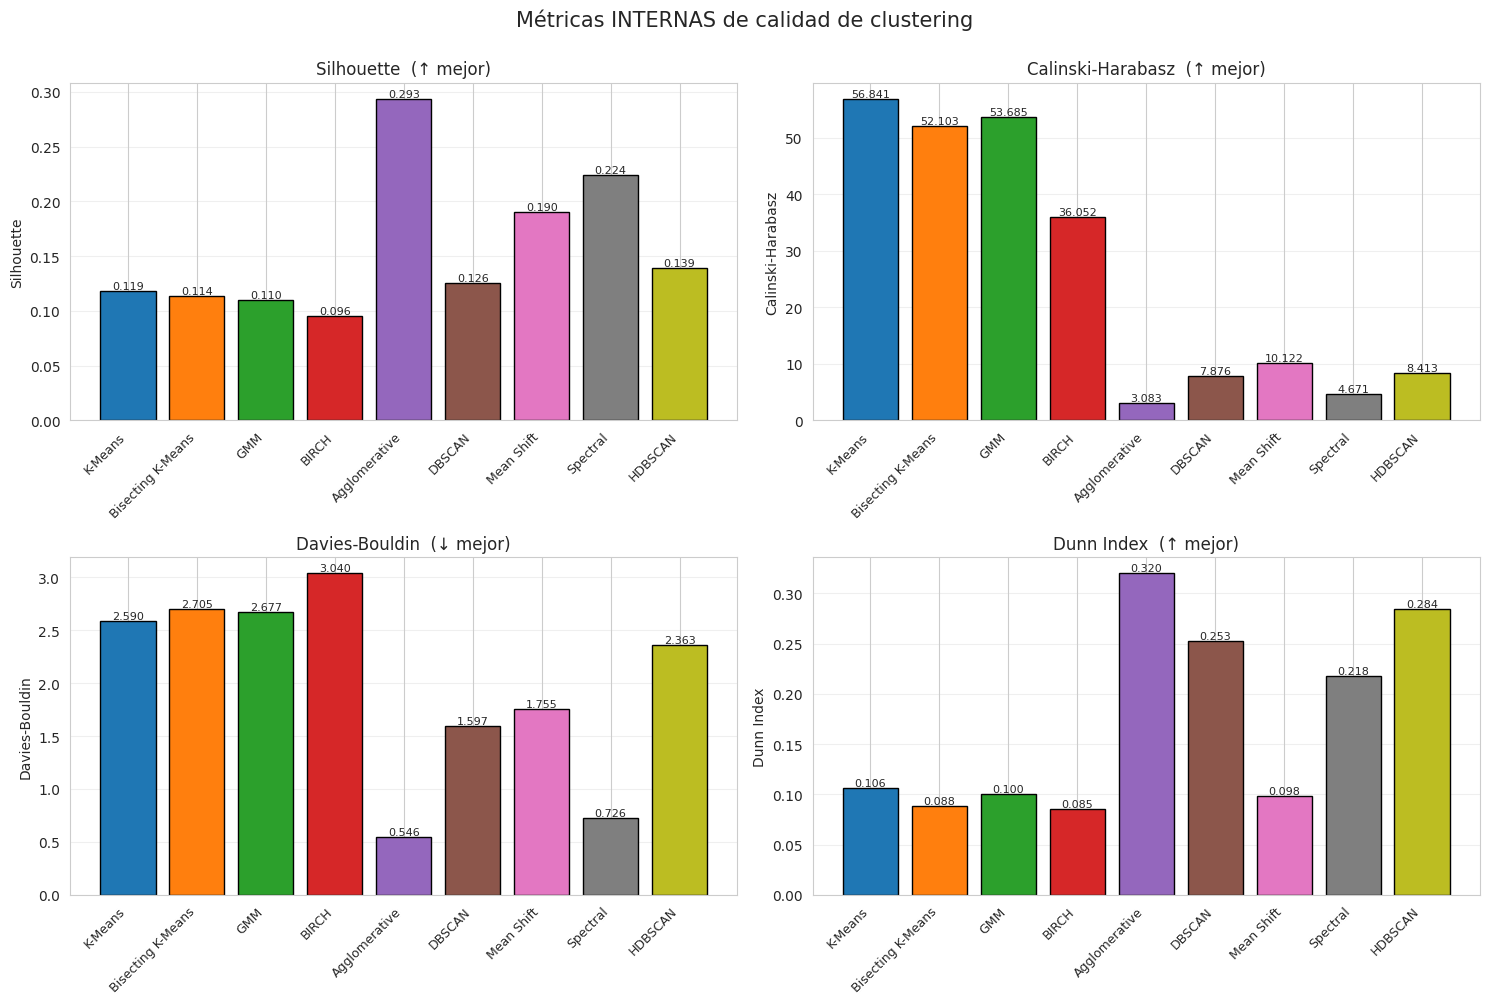

In [53]:
internal_metrics = ["Silhouette", "Calinski-Harabasz", "Davies-Bouldin", "Dunn Index"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

colors = sns.color_palette("tab10", n_colors=len(metrics_df))

for idx, metric in enumerate(internal_metrics):
    ax = axes[idx]
    vals = metrics_df[metric].dropna()
    bars = ax.bar(range(len(vals)), vals.values,
                  color=[colors[metrics_df.index.get_loc(a)] for a in vals.index],
                  edgecolor="black")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(metric)

    # Indicar dirección "mejor"
    if metric in ["Silhouette", "Calinski-Harabasz", "Dunn Index"]:
        arrow = "↑ mejor"
    else:
        arrow = "↓ mejor"
    ax.set_title(f"{metric}  ({arrow})", fontsize=12)

    # Anotar valores
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.grid(alpha=0.3, axis="y")

plt.suptitle("Métricas INTERNAS de calidad de clustering",
             fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

### 20.6 Visualización comparativa: métricas externas (vs Channel)

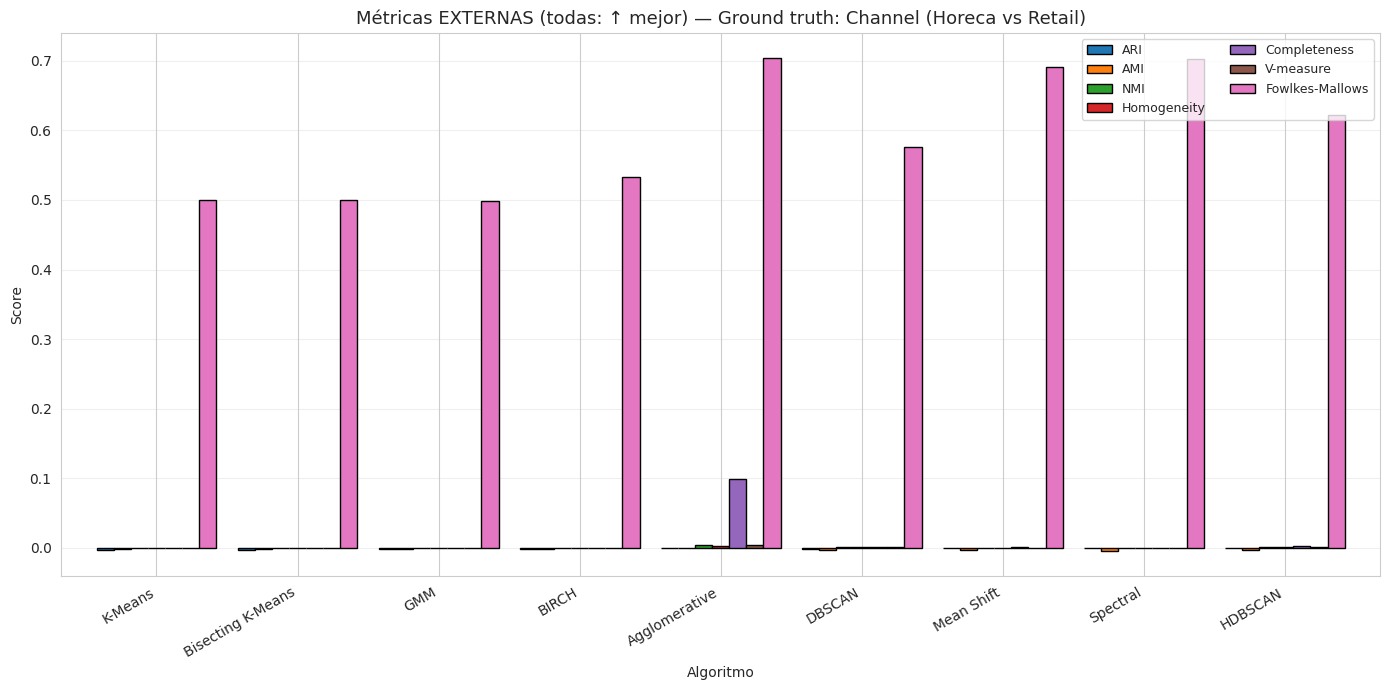

In [54]:
external_metrics = ["ARI", "AMI", "NMI", "Homogeneity", "Completeness", "V-measure", "Fowlkes-Mallows"]

fig, ax = plt.subplots(figsize=(14, 7))
plot_df = metrics_df[external_metrics]
plot_df.plot(kind="bar", ax=ax, edgecolor="black", width=0.85)

ax.set_ylabel("Score")
ax.set_xlabel("Algoritmo")
ax.set_title("Métricas EXTERNAS (todas: ↑ mejor) — Ground truth: Channel (Horeca vs Retail)",
             fontsize=13)
ax.legend(loc="upper right", fontsize=9, ncol=2)
ax.grid(alpha=0.3, axis="y")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 20.7 Heatmap resumen de todas las métricas

Un heatmap normalizado facilita ver de un vistazo qué algoritmo domina en qué familia de métricas.

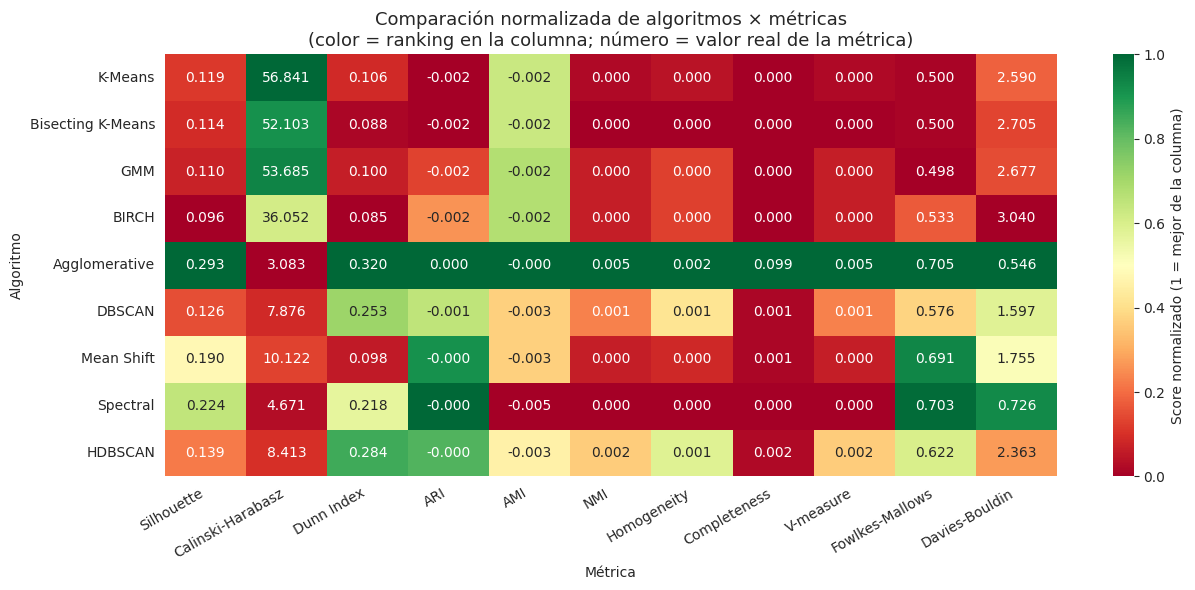

In [55]:
from matplotlib.colors import TwoSlopeNorm

# Normalizamos cada columna al rango [0,1] considerando la dirección "mejor"
# Métricas donde MAYOR es mejor
higher_better = ["Silhouette", "Calinski-Harabasz", "Dunn Index",
                 "ARI", "AMI", "NMI", "Homogeneity",
                 "Completeness", "V-measure", "Fowlkes-Mallows"]
# Métricas donde MENOR es mejor
lower_better  = ["Davies-Bouldin"]

metric_cols = higher_better + lower_better
norm_df = metrics_df[metric_cols].copy()

for col in metric_cols:
    vals = norm_df[col].astype(float)
    v_min, v_max = np.nanmin(vals), np.nanmax(vals)
    if v_max - v_min < 1e-12:
        norm_df[col] = 0.5
        continue
    if col in higher_better:
        norm_df[col] = (vals - v_min) / (v_max - v_min)
    else:  # lower_better -> invertir
        norm_df[col] = 1 - (vals - v_min) / (v_max - v_min)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(norm_df, annot=metrics_df[metric_cols].values, fmt=".3f",
            cmap="RdYlGn", vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "Score normalizado (1 = mejor de la columna)"})
ax.set_title("Comparación normalizada de algoritmos × métricas\n"
             "(color = ranking en la columna; número = valor real de la métrica)",
             fontsize=13)
ax.set_xlabel("Métrica")
ax.set_ylabel("Algoritmo")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 20.8 Silhouette diagram (análisis por punto)

El **Silhouette diagram** desglosa el silhouette por cada punto individual, revelando puntos mal asignados dentro de cada cluster.

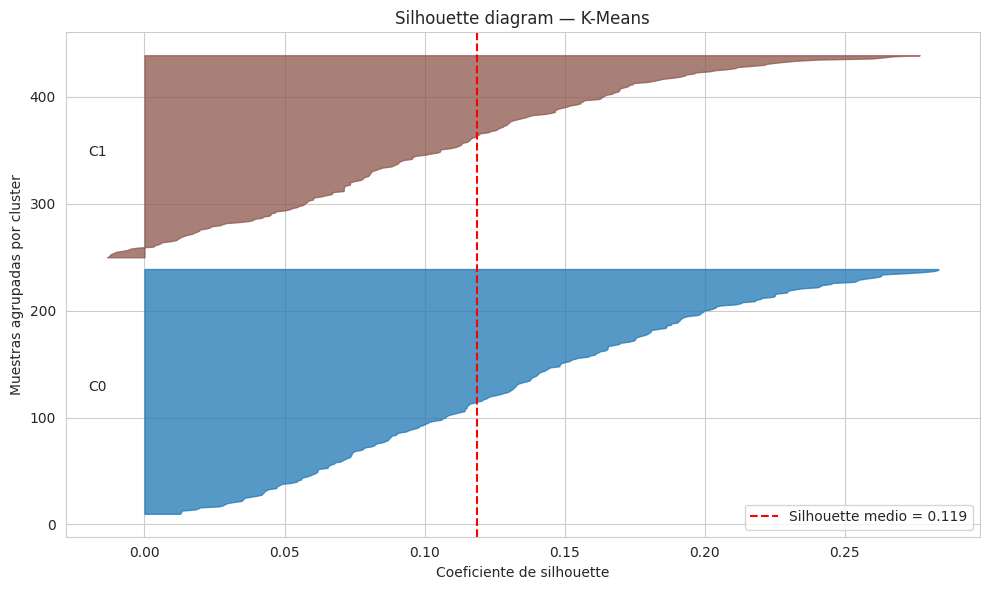

In [56]:
import matplotlib.cm as cm

def plot_silhouette_diagram(X, labels, title):
    """Diagrama de silhouette por punto, agrupado por cluster."""
    n_clusters = len(set(labels))
    silhouette_avg = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)

    fig, ax = plt.subplots(figsize=(10, 6))
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette = sample_silhouette_values[labels == i]
        ith_cluster_silhouette.sort()
        size_i = ith_cluster_silhouette.shape[0]
        y_upper = y_lower + size_i

        color = cm.tab10(float(i) / max(n_clusters, 1))
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0, ith_cluster_silhouette,
            facecolor=color, edgecolor=color, alpha=0.75
        )
        ax.text(-0.02, y_lower + 0.5 * size_i, f"C{i}", fontsize=10)
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_avg, color="red", linestyle="--",
               label=f"Silhouette medio = {silhouette_avg:.3f}")
    ax.set_xlabel("Coeficiente de silhouette")
    ax.set_ylabel("Muestras agrupadas por cluster")
    ax.set_title(f"Silhouette diagram — {title}", fontsize=12)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# Aplicamos al K-Means final
plot_silhouette_diagram(X, labels_kmeans, "K-Means")

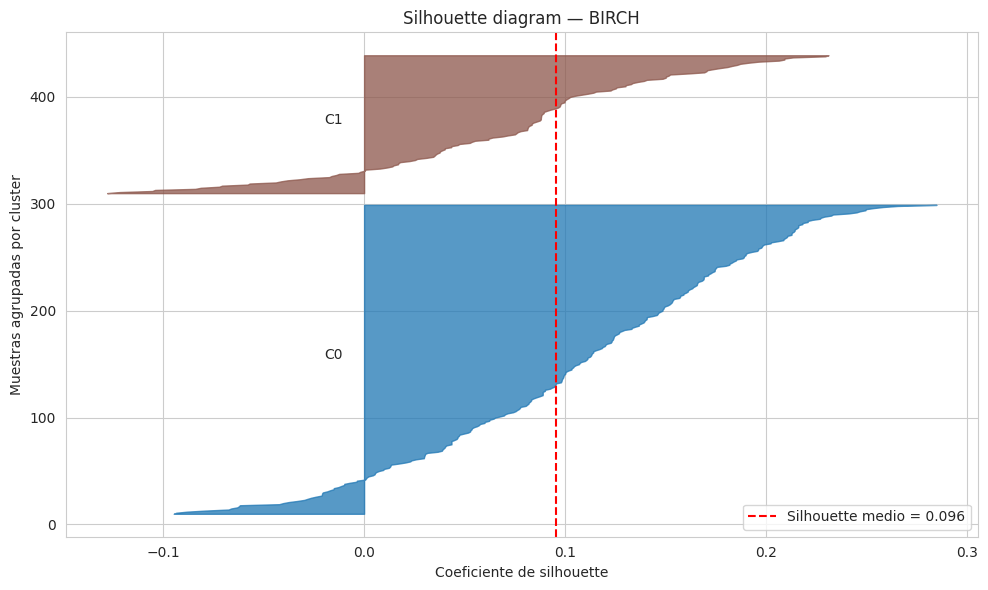

In [57]:
plot_silhouette_diagram(X, labels_birch, "BIRCH")

**Cómo leer el diagrama de silhouette:**
- Cada franja horizontal representa un punto; el ancho es su coeficiente individual.
- Franjas anchas y todas por encima de la línea roja ⇒ cluster bien formado.
- Franjas por debajo de la línea o con silhouette negativo ⇒ puntos mal asignados o mezclados con otro cluster.
- Diferencias grandes de tamaño entre clusters pueden indicar desequilibrio.

## 21. Conclusiones

| Aspecto | Hallazgo |
|---|---|
| **Transformación logarítmica** | `log1p()` es esencial antes de escalar — reduce la asimetría fuerte del gasto y mejora la geometría para métodos basados en distancia. |
| **Selección de k** | Elbow + Silhouette + Calinski-Harabasz + Davies-Bouldin dan una decisión mucho más robusta que Silhouette solo. |
| **K-Means** | Rápido y sencillo; buen baseline. Silhouette y ARI razonables cuando la estructura es aproximadamente esférica. |
| **Bisecting K-Means** | Muy similar a K-Means en este dataset, pero más determinístico y con estructura jerárquica implícita. |
| **BIRCH** | Escalable a datasets muy grandes. Su `threshold` controla granularidad y debe tunearse: valores muy bajos generan cientos de sub-clusters; valores muy altos colapsan la estructura. |
| **Agglomerative (Ward)** | Comparable a K-Means en calidad; el dendrograma da una visión jerárquica útil para explicar los merges. |
| **GMM** | Añade soft-clustering y modela clusters elípticos. El BIC/AIC complementan a Silhouette para elegir `k`. |
| **DBSCAN / HDBSCAN** | Útiles cuando hay ruido genuino en los datos. En este dataset (ya limpio de outliers por IQR) tienden a marcar pocos puntos como ruido y funden todo en 1-2 clusters. |
| **Mean Shift / Spectral** | Alternativas menos utilizadas en producción por su costo O(n²) pero útiles para clusters no convexos. |
| **Métricas internas vs externas** | Las internas son las únicas disponibles en un caso real de segmentación (sin ground truth). Las externas aquí sirven de **validación pedagógica** al usar `Channel` como referencia. |
| **Silhouette no es suficiente** | Un algoritmo puede tener silhouette alto y ARI bajo — es decir, agrupa geométricamente bien pero no recupera la segmentación de negocio. La combinación de métricas es la clave. |
| **Insight de este dataset** | En nuestros resultados **todos** los algoritmos tuvieron ARI ≈ 0 vs `Channel`. Esto no es un fallo del clustering — es evidencia de que, tras el filtrado IQR, la estructura geométrica dominante en los gastos (log-escalados) es **ortogonal** al canal Horeca/Retail. Los clusters describen "cómo gastan" los clientes, no "qué tipo de negocio son". |

### Recomendaciones para trabajo futuro
- Explorar **Spectral Co-clustering** para clientes × productos simultáneamente.
- Usar **UMAP** en lugar de t-SNE para preservar mejor la estructura global.
- Probar **Deep Clustering** (autoencoder + K-Means conjunto) con datasets más grandes.
- Añadir features derivadas: proporciones de gasto (Fresh / Total, etc.) para captar mejor los perfiles de negocio.
- Validar la estabilidad de los clusters con **bootstrap resampling** (índice de Jaccard entre corridas).